# Presentación — Experimentos Seleccionados para la Tesis

**Experimentos:** 5 univariados (1.1, 1.4, 1.7, 1.10, 1.19) · 3 multivariados (2.1, 2.5, 2.7) · 3 covariados (3.1, 3.4, 3.6)  
**Setup:** T ∈ {50, 200} | H = 24 | R = 500 | Semilla = 3649  
**Métricas:** RMSE, MAE, CRPS (menor = mejor) · COV_80/95 (nominal 0.80/0.95) · WINKLER_95 (menor = mejor)  

Los resultados se cargan desde CSVs ya cacheados.  
Las gráficas de simulación representativa corren 1 réplica fresca (Chronos ~30 s en total).

---

In [ ]:
import os, warnings
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"
warnings.filterwarnings("ignore")

import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

# ── Globales ──────────────────────────────────────────────────────────
SEED   = 3649
H      = 24
R      = 500
T_LIST = [50, 200]
RESULTS_UNI  = Path('results/univariate')
RESULTS_MV   = Path('results/multivariate')
RESULTS_COV  = Path('results/covariates')

# ── Paleta visual (identidad de la tesis) ─────────────────────────────
C_HIST    = '#4C72B0'   # historia / ground truth
C_CHRONOS = '#9672B6'   # Chronos (siempre violeta)
C_CLASSIC = '#2A9D8F'   # modelos clásicos (verde-azulado)
CLASSIC_LS = ['-', '--', '-.', ':']  # linestyles para múltiples clásicos

def _is_chronos(name: str) -> bool:
    return 'Chronos' in name or 'chronos' in name.lower()

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 9,
    'axes.facecolor': 'white',
    'figure.facecolor': 'white',
    'axes.grid': True,
    'grid.color': '#e8e8e8',
    'grid.linewidth': 0.8,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
pd.set_option('display.float_format', '{:.4f}'.format)

# ── Chronos (cargado una sola vez) ────────────────────────────────────
print('Cargando Chronos-2 (~30 s)...')
from mectesis.models.chronos import ChronosModel
from mectesis.models.chronos_multivariate import ChronosMultivariateModel, ChronosPerVarModel
from mectesis.models.chronos_covariate import ChronosCovariateModel, ChronosMultivariateCovariateModel

_chronos_base   = ChronosModel(device='cpu')
chronos_uni     = _chronos_base
chronos_mv      = ChronosMultivariateModel(_chronos_base)
chronos_mv_ind  = ChronosPerVarModel(_chronos_base)
chronos_cov1    = ChronosCovariateModel(_chronos_base, n_covariates=1)
chronos_mv_cov1 = ChronosMultivariateCovariateModel(_chronos_base, n_covariates=1)
print('Chronos-2 listo.')


Cargando Chronos-2 (~30 s)...
Chronos-2 listo.


In [29]:
# ══ Carga de resultados ═════════════════════════════════════════════════

def _load(path):
    df = pd.read_csv(path)
    return {
        m: grp.drop(columns='model').reset_index(drop=True)
        for m, grp in df.groupby('model', sort=False)
    }

def _load_mv(path):
    df = pd.read_csv(path)
    out = {}
    for m, mg in df.groupby('model', sort=False):
        out[m] = {
            int(v): vg.drop(columns=['model','var']).reset_index(drop=True)
            for v, vg in mg.groupby('var', sort=True)
        }
    return out

def load_uni(exp_id):
    eid = exp_id.replace('.', '_')
    return {(T, R): _load(RESULTS_UNI / f'exp_{eid}_T{T}_R{R}.csv') for T in T_LIST}

def load_mv(exp_id):
    eid = exp_id.replace('.', '_')
    return {(T, R): _load_mv(RESULTS_MV / f'exp_{eid}_T{T}_R{R}.csv') for T in T_LIST}

def load_cov(exp_id):
    eid = exp_id.replace('.', '_')
    return {(T, R): _load(RESULTS_COV / f'exp_{eid}_T{T}_R{R}.csv') for T in T_LIST}

def load_mv_cov(exp_id):
    eid = exp_id.replace('.', '_')
    return {(T, R): _load_mv(RESULTS_COV / f'exp_{eid}_T{T}_R{R}.csv') for T in T_LIST}


# ══ avg_all extractor ═══════════════════════════════════════════════════

def _avg(df):
    row = df[df['horizon'] == 'avg_all']
    if row.empty:
        return df.select_dtypes('number').mean()
    return row.iloc[0]


# ══ Tabla estilizada ════════════════════════════════════════════════════

_MCOLS = ['rmse','mae','crps','cov_80','cov_95','width_95','winkler_95']
_ERR   = ['rmse','mae','crps','winkler_95','width_95']
_COV   = ['cov_80','cov_95']

def styled_table(all_results, title='', is_mv=False):
    rows = []
    for (T, Rr), res_TR in sorted(all_results.items()):
        if is_mv:
            for mname, var_dict in res_TR.items():
                avgs = pd.DataFrame([_avg(df) for df in var_dict.values()])
                combined = avgs.mean(numeric_only=True)
                row = {'T': T, 'Modelo': mname}
                for c in _MCOLS:
                    if c in combined.index:
                        row[c] = round(float(combined[c]), 4)
                rows.append(row)
        else:
            for mname, df in res_TR.items():
                avg = _avg(df)
                row = {'T': T, 'Modelo': mname}
                for c in _MCOLS:
                    if c in avg.index:
                        try:    row[c] = round(float(avg[c]), 4)
                        except: row[c] = float('nan')
                rows.append(row)

    df_out = pd.DataFrame(rows).set_index(['T', 'Modelo'])
    err_p = [c for c in _ERR if c in df_out.columns]
    cov_p = [c for c in _COV if c in df_out.columns]
    sty = df_out.style.format(precision=4, na_rep='—')
    if err_p: sty = sty.background_gradient(subset=err_p, cmap='RdYlGn_r')
    if cov_p: sty = sty.background_gradient(subset=cov_p, cmap='RdYlGn')
    if title: sty = sty.set_caption(title)
    display(sty)
    return df_out


# ══ Métricas vs horizonte ════════════════════════════════════════════════

def plot_metrics_horizon(all_results,
                         metrics=('rmse','crps','cov_95','winkler_95'),
                         title='', is_mv=False):
    keys = sorted(all_results.keys())
    fig, axes = plt.subplots(len(metrics), len(keys),
                             figsize=(6.5*len(keys), 3.0*len(metrics)),
                             squeeze=False)
    for col, (T, Rr) in enumerate(keys):
        res_TR = all_results[(T, Rr)]
        # ── Construir series por modelo ──────────────────────────────
        if is_mv:
            model_dfs = {}
            for mname, var_dict in res_TR.items():
                dfs = [df[df['horizon'] != 'avg_all'].copy() for df in var_dict.values()]
                for d in dfs: d['horizon'] = pd.to_numeric(d['horizon'])
                model_dfs[mname] = (pd.concat(dfs)
                                      .groupby('horizon').mean(numeric_only=True)
                                      .reset_index())
        else:
            model_dfs = {}
            for mname, df in res_TR.items():
                d = df[df['horizon'] != 'avg_all'].copy()
                d['horizon'] = pd.to_numeric(d['horizon'])
                model_dfs[mname] = d

        # ── Asignar estilos ──────────────────────────────────────────
        classic_idx = 0
        ls_map = {}
        for m in model_dfs:
            if _is_chronos(m):
                ls_map[m] = ('-', C_CHRONOS)
            else:
                ls_map[m] = (CLASSIC_LS[classic_idx % len(CLASSIC_LS)], C_CLASSIC)
                classic_idx += 1

        for row, metric in enumerate(metrics):
            ax = axes[row][col]
            ax.axvline(12.5, color='#999999', ls=':', lw=0.9, alpha=0.7)
            for mname, df_h in model_dfs.items():
                if metric not in df_h.columns: continue
                ls, color = ls_map[mname]
                ax.plot(df_h['horizon'], df_h[metric],
                        label=mname, color=color, ls=ls, lw=1.5, alpha=0.9)
            ax.set_title(f'T={T} — {metric.upper()}', fontsize=9.5, pad=3)
            ax.set_xlabel('Horizonte h', fontsize=8.5)
            ax.set_ylabel(metric.upper(), fontsize=8.5)
            ax.legend(fontsize=7.5)

    if title: fig.suptitle(title, fontsize=11, y=1.01)
    plt.tight_layout()
    plt.show()
    return fig


In [30]:
# ══ Helpers internos ════════════════════════════════════════════════════

def _assign_styles(model_names):
    classic_idx = 0
    styles = {}
    for n in model_names:
        if _is_chronos(n):
            styles[n] = (C_CHRONOS, '-')
        else:
            styles[n] = (C_CLASSIC, CLASSIC_LS[classic_idx % len(CLASSIC_LS)])
            classic_idx += 1
    return styles

def _get_name(m):
    return m.name if hasattr(m, 'name') else str(type(m).__name__)

def _draw_context(ax, x_tr, y_tr_1d, x_te, y_te_1d, n_context):
    x_all = np.concatenate([x_tr[-n_context:], x_te])
    y_all = np.concatenate([y_tr_1d[-n_context:], y_te_1d])
    ax.plot(x_all, y_all, color=C_HIST, lw=1.3, alpha=0.85, label='Histórico')
    ax.axvline(x_tr[-1] + 0.5, color='#999999', ls=':', lw=0.9, alpha=0.7)

def _shared_legend(fig, axes):
    from matplotlib.patches import Patch
    all_handles, all_labels, seen = [], [], set()
    for row_ax in axes[:, 0]:
        for h, l in zip(*row_ax.get_legend_handles_labels()):
            if l not in seen:
                seen.add(l); all_handles.append(h); all_labels.append(l)
    all_handles.append(Patch(facecolor='#888888', alpha=0.25, label='Intervalo 80%'))
    all_labels.append('Intervalo 80%')
    fig.legend(all_handles, all_labels,
               loc='lower center', ncol=len(all_handles),
               bbox_to_anchor=(0.5, 1.0), fontsize=8.5,
               frameon=True, framealpha=0.9)

def _get_mc_rmse(mc_results, T, mname, R=500, var_idx=None):
    if mc_results is None:
        return None
    try:
        res_T = mc_results.get((T, R))
        if res_T is None or mname not in res_T:
            return None
        data = res_T[mname]
        if isinstance(data, dict):  # multivariate: {var_idx: DataFrame}
            key = var_idx if (var_idx is not None and var_idx in data) else min(data.keys())
            df = data[key]
        else:
            df = data
        return float(_avg(df).get('rmse', float('nan')))
    except Exception:
        return None


# ══ Univariado ══════════════════════════════════════════════════════════

def plot_rep_uni(dgp, make_models, dgp_params, T_list=T_LIST,
                 H=H, seed=SEED, title='', n_context=50, mc_results=None):
    n_models = len(make_models(T_list[0]))
    fig, axes = plt.subplots(n_models, len(T_list),
                             figsize=(13, 2.8 * n_models), squeeze=False)
    fig.patch.set_facecolor('white')

    for col, T in enumerate(T_list):
        dgp.rng = np.random.default_rng(seed)
        y = dgp.simulate(T=T, **dgp_params)
        y_train, y_test = y[:-H], y[-H:]
        x_tr = np.arange(len(y_train))
        x_te = np.arange(len(y_train), T)
        models  = make_models(T)
        mnames  = [_get_name(m) for m in models]
        styles  = _assign_styles(mnames)

        for row, m in enumerate(models):
            ax = axes[row][col]
            ax.spines[['top', 'right']].set_visible(True)
            m.fit(y_train)
            y_hat = m.forecast(H)
            mname = mnames[row]
            color, ls = styles[mname]
            rmse_v = float(np.sqrt(np.nanmean((y_hat - y_test)**2)))
            _draw_context(ax, x_tr, y_train, x_te, y_test, n_context)
            ax.plot(x_te, y_hat, color=color, ls=ls, lw=1.5, label=mname)
            if getattr(m, 'supports_intervals', False):
                lo, hi = m.forecast_intervals(H, level=0.80)
                ax.fill_between(x_te, lo, hi, color=color, alpha=0.15)
            ax.set_title(mname, fontweight='bold', fontsize=9.5, pad=4)
            _mc_r = _get_mc_rmse(mc_results, T, mname)
            _rmse_str = f'{_mc_r:.3f}' if _mc_r is not None else f'{rmse_v:.3f}*'
            ax.annotate(f'T={T}  |  RMSE={_rmse_str}',
                        xy=(0.99, 0.97), xycoords='axes fraction',
                        ha='right', va='top', fontsize=7.5, color='#555555')
            ax.set_xlabel('t', fontsize=8)

    _shared_legend(fig, axes)
    plt.tight_layout()
    fig.subplots_adjust(top=0.93)
    plt.show()
    return fig


# ══ Multivariado ════════════════════════════════════════════════════════

def plot_rep_mv(dgp, make_models, T_list=T_LIST,
                H=H, seed=SEED, title='', var_idx=0, n_context=50, mc_results=None):
    n_models = len(make_models(T_list[0]))
    fig, axes = plt.subplots(n_models, len(T_list),
                             figsize=(13, 2.8 * n_models), squeeze=False)
    fig.patch.set_facecolor('white')

    for col, T in enumerate(T_list):
        dgp.rng = np.random.default_rng(seed)
        y = dgp.simulate(T=T)
        y_train, y_test = y[:-H], y[-H:]
        x_tr = np.arange(len(y_train))
        x_te = np.arange(len(y_train), T)
        y_tr_v = y_train[:, var_idx]
        y_te_v = y_test[:, var_idx]
        models  = make_models(T)
        mnames  = [_get_name(m) for m in models]
        styles  = _assign_styles(mnames)

        for row, m in enumerate(models):
            ax = axes[row][col]
            ax.spines[['top', 'right']].set_visible(True)
            m.fit(y_train)
            y_hat_full = m.forecast(H)  # (H, k)
            y_hat = y_hat_full[:, var_idx]
            mname = mnames[row]
            color, ls = styles[mname]
            rmse_v = float(np.sqrt(np.nanmean((y_hat - y_te_v)**2)))
            _draw_context(ax, x_tr, y_tr_v, x_te, y_te_v, n_context)
            ax.plot(x_te, y_hat, color=color, ls=ls, lw=1.5, label=mname)
            if getattr(m, 'supports_intervals', False):
                lo_f, hi_f = m.forecast_intervals(H, level=0.80)  # (H, k)
                ax.fill_between(x_te, lo_f[:, var_idx], hi_f[:, var_idx],
                                color=color, alpha=0.15)
            ax.set_title(mname, fontweight='bold', fontsize=9.5, pad=4)
            _mc_r = _get_mc_rmse(mc_results, T, mname, var_idx=var_idx)
            _rmse_str = f'{_mc_r:.3f}' if _mc_r is not None else f'{rmse_v:.3f}*'
            ax.annotate(f'T={T}  |  RMSE Y{var_idx}={_rmse_str}',
                        xy=(0.99, 0.97), xycoords='axes fraction',
                        ha='right', va='top', fontsize=7.5, color='#555555')
            ax.set_xlabel('t', fontsize=8)

    _shared_legend(fig, axes)
    plt.tight_layout()
    fig.subplots_adjust(top=0.93)
    plt.show()
    return fig


# ══ Covariado ═══════════════════════════════════════════════════════════

def plot_rep_cov(dgp, make_models, dgp_params, T_list=T_LIST,
                 H=H, seed=SEED, title='', is_mv=False, var_idx=0, n_context=50, mc_results=None):
    n_models = len(make_models(T_list[0]))
    fig, axes = plt.subplots(n_models, len(T_list),
                             figsize=(13, 2.8 * n_models), squeeze=False)
    fig.patch.set_facecolor('white')

    for col, T in enumerate(T_list):
        dgp.rng = np.random.default_rng(seed)
        data    = dgp.simulate(T=T, **dgp_params)
        y_full  = data['y']
        X_full  = data['X']
        y_train_f, y_test_f = y_full[:-H], y_full[-H:]
        X_train,   X_future = X_full[:-H], X_full[-H:]

        if is_mv:
            y_tr_v = y_train_f[:, var_idx]
            y_te_v = y_test_f[:, var_idx]
        else:
            y_tr_v = y_train_f
            y_te_v = y_test_f

        x_tr = np.arange(len(y_tr_v))
        x_te = np.arange(len(y_tr_v), T)
        models  = make_models(T)
        mnames  = [_get_name(m) for m in models]
        styles  = _assign_styles(mnames)

        for row, m in enumerate(models):
            ax = axes[row][col]
            ax.spines[['top', 'right']].set_visible(True)
            m.fit(y_train_f, X_train)
            y_hat_full = m.forecast(H, X_future=X_future)
            if is_mv and np.ndim(y_hat_full) > 1:
                y_hat = y_hat_full[:, var_idx]
            else:
                y_hat = np.asarray(y_hat_full).ravel()
            mname  = mnames[row]
            color, ls = styles[mname]
            valid  = ~np.isnan(y_hat)
            rmse_v = (float(np.sqrt(np.mean((y_hat[valid] - y_te_v[valid])**2)))
                      if valid.any() else float('nan'))
            _draw_context(ax, x_tr, y_tr_v, x_te, y_te_v, n_context)
            ax.plot(x_te, y_hat, color=color, ls=ls, lw=1.5, label=mname)
            if getattr(m, 'supports_intervals', False):
                lo_f, hi_f = m.forecast_intervals(H, level=0.80, X_future=X_future)
                if is_mv and np.ndim(lo_f) > 1:
                    lo_f, hi_f = lo_f[:, var_idx], hi_f[:, var_idx]
                ax.fill_between(x_te, lo_f, hi_f, color=color, alpha=0.15)
            ax.set_title(mname, fontweight='bold', fontsize=9.5, pad=4)
            _mc_vi = var_idx if is_mv else None
            _mc_r = _get_mc_rmse(mc_results, T, mname, var_idx=_mc_vi)
            _rmse_str = f'{_mc_r:.3f}' if _mc_r is not None else f'{rmse_v:.3f}*'
            ax.annotate(f'T={T}  |  RMSE={_rmse_str}',
                        xy=(0.99, 0.97), xycoords='axes fraction',
                        ha='right', va='top', fontsize=7.5, color='#555555')
            ax.set_xlabel('t', fontsize=8)

    _shared_legend(fig, axes)
    plt.tight_layout()
    fig.subplots_adjust(top=0.93)
    plt.show()
    return fig


In [31]:
# ── DGPs univariados ──────────────────────────────────────────────────
from mectesis.dgp.ar       import AR1
from mectesis.dgp.rw       import RandomWalk
from mectesis.dgp.seasonal import SeasonalDGP
from mectesis.dgp.garch    import AR1GARCH
from mectesis.dgp.ar_trend import AR1WithTrend

# ── DGPs multivariados ────────────────────────────────────────────────
from mectesis.dgp.var_dgp  import VARDGP
from mectesis.dgp.vecm_dgp import VECMBivariateDGP

# ── DGPs covariados ───────────────────────────────────────────────────
from mectesis.dgp.arimax_dgp  import ARIMAX_DGP
from mectesis.dgp.varx_dgp    import VARX_DGP
from mectesis.dgp.adl_ecm_dgp import ADL_ECM_DGP

# ── Modelos clásicos ──────────────────────────────────────────────────
from mectesis.models.arima          import ARIMAModel
from mectesis.models.sarima_model   import SARIMAModel
from mectesis.models.garch_model    import ARGARCHModel
from mectesis.models.theta_model    import ThetaModel
from mectesis.models.var_model      import VARModel, VECMModel
from mectesis.models.sarimax_model  import SARIMAXModel
from mectesis.models.varmax_model   import VARMAXModel
from mectesis.models.ardl_model     import ARDLModel

print('Imports OK.')


Imports OK.


In [32]:
# ── Univariados ───────────────────────────────────────────────────────
dgp_1_1  = AR1(seed=SEED)
dgp_1_4  = RandomWalk(seed=SEED)
dgp_1_7  = SeasonalDGP(seed=SEED)
dgp_1_10 = AR1GARCH(seed=SEED)
dgp_1_19 = AR1WithTrend(seed=SEED)

# ── Multivariados ─────────────────────────────────────────────────────
_A1_21  = np.array([[0.5, 0.1], [0.1, 0.5]])
_Sig2   = np.array([[1.0, 0.3], [0.3, 1.0]])
dgp_2_1  = VARDGP(seed=SEED, A_list=[_A1_21], Sigma=_Sig2)

_A1_25  = np.array([[0.3, 0.05, 0.0,  0.0,  0.0 ],
                    [0.05, 0.3, 0.05, 0.0,  0.0 ],
                    [0.0, 0.05, 0.3,  0.05, 0.0 ],
                    [0.0,  0.0, 0.05, 0.3,  0.05],
                    [0.0,  0.0, 0.0,  0.05, 0.3 ]])
_Sig5   = np.array([[1.0, 0.2, 0.0, 0.0, 0.0],
                    [0.2, 1.0, 0.2, 0.0, 0.0],
                    [0.0, 0.2, 1.0, 0.2, 0.0],
                    [0.0, 0.0, 0.2, 1.0, 0.2],
                    [0.0, 0.0, 0.0, 0.2, 1.0]])
dgp_2_5  = VARDGP(seed=SEED, A_list=[_A1_25], Sigma=_Sig5)

dgp_2_7  = VECMBivariateDGP(seed=SEED)  # parámetros por defecto del exp 2.7

# ── Covariados ────────────────────────────────────────────────────────
dgp_3_1  = ARIMAX_DGP(seed=SEED)
dgp_3_4  = VARX_DGP(
    seed=SEED,
    A=[[0.5, 0.1], [0.1, 0.5]],
    gamma=[0.5, 0.3],
    Sigma=[[1.0, 0.3], [0.3, 1.0]],
    sigma_x=1.0, rho_x=0.7,
)
dgp_3_6  = ADL_ECM_DGP(seed=SEED)

print('DGPs creados.')


DGPs creados.


---

# Experimentos Univariados

Seleccionados: **1.1** (baseline) · **1.4** (misspecificación) · **1.7** (límite estructural) · **1.10** (brecha CRPS) · **1.19** (colapso clásico)  

Modelos clásicos correctamente especificados vs Chronos-2 (zero-shot).

## Exp 1.1 — AR(1) φ=0.3, baja persistencia

**DGP:** $Y_t = 0.3\,Y_{t-1} + \varepsilon_t, \quad \varepsilon_t \sim \mathcal{N}(0,1)$

**Caso base.** ARIMA correctamente especificado vs Chronos zero-shot. Evalúa si Chronos recupera la estructura AR(1) estacionaria sin estimarla explícitamente.

**Hipótesis:** ARIMA domina en RMSE y CRPS. Chronos sobrecobertura (~2× ancho de intervalo).

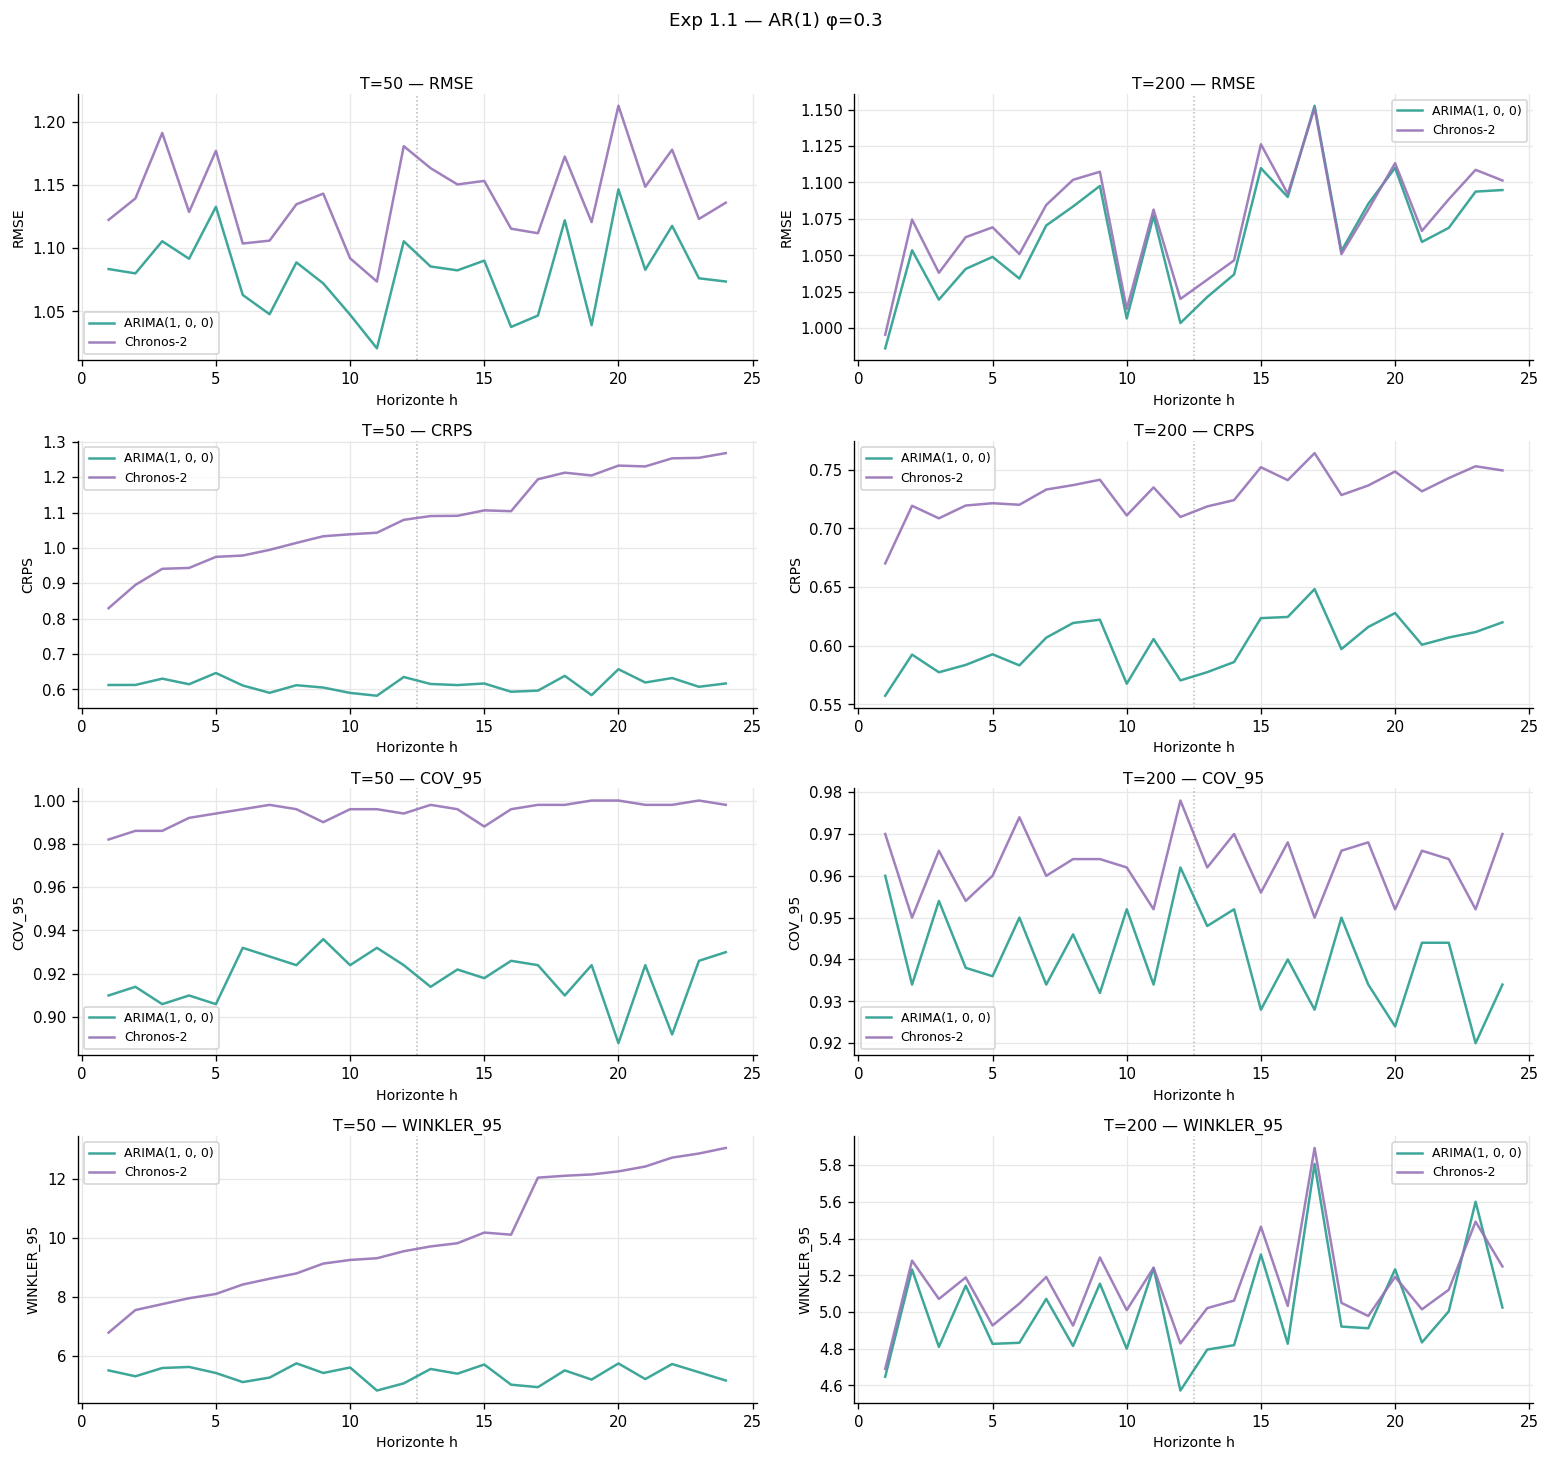

In [33]:
res_1_1 = load_uni('1.1')
styled_table(res_1_1, title='Exp 1.1 — AR(1) φ=0.3')
_ = plot_metrics_horizon(res_1_1, title='Exp 1.1 — AR(1) φ=0.3')


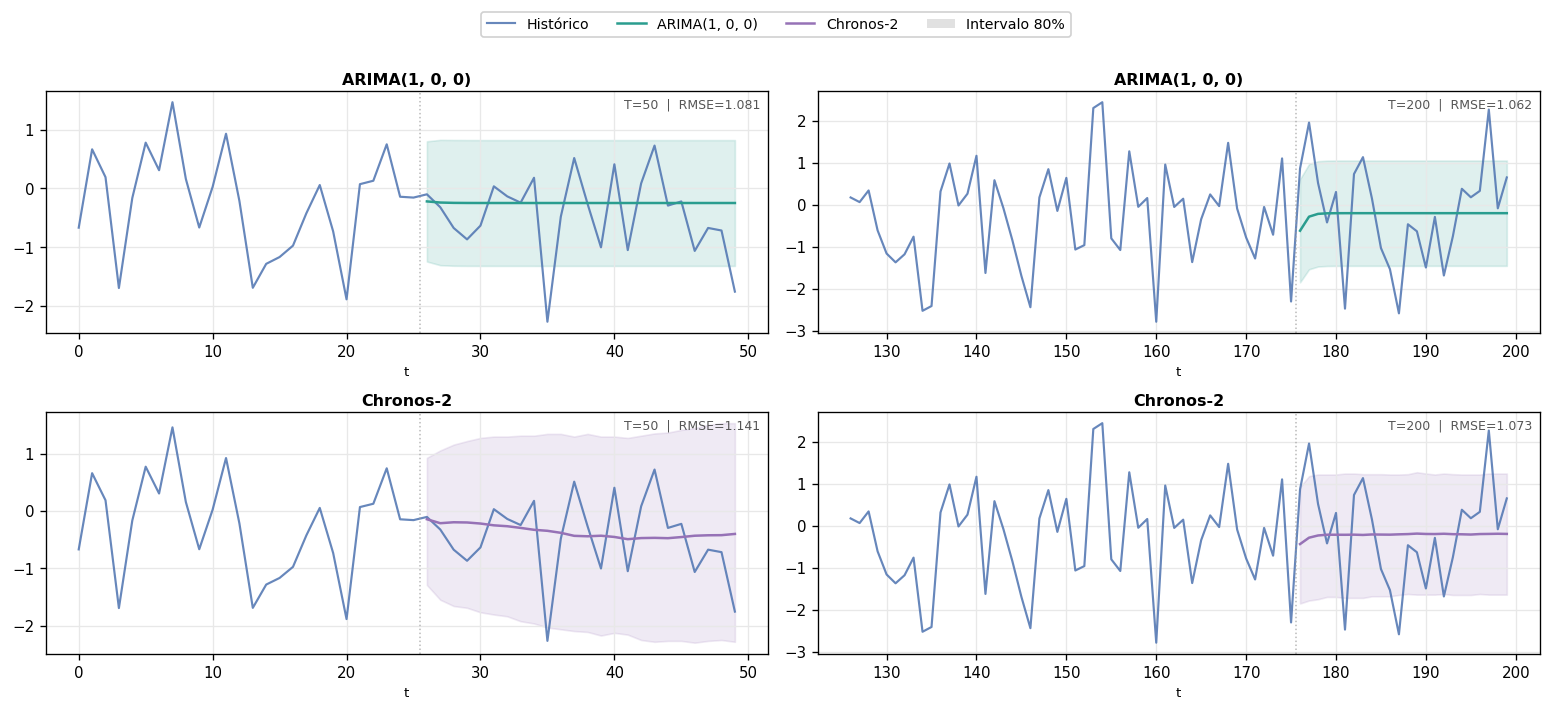

In [34]:
make_models_1_1 = lambda T: [ARIMAModel((1,0,0)), chronos_uni]
_ = plot_rep_uni(dgp_1_1, make_models_1_1, {'phi': 0.3},
                 title='Exp 1.1 — AR(1) φ=0.3', mc_results=res_1_1)


## Exp 1.4 — Random Walk con drift=0.5 *(inversión: Chronos gana)*

**DGP:** $Y_t = 0.5 + Y_{t-1} + \varepsilon_t, \quad \varepsilon_t \sim \mathcal{N}(0,1)$

**El resultado más relevante del bloque.** ARIMA(0,1,0) sin constante no captura el drift: el sesgo crece linealmente con el horizonte ($\text{bias} \approx 0.5h$). Chronos identifica el drift desde el contexto de la serie (zero-shot). La ventaja de Chronos se amplía con T (RMSE cae 32% de T=50 a T=200).

**Nota:** La misspecificación del drift es un error frecuente en la práctica.

**Hipótesis:** Chronos domina en RMSE, MAE y Winkler en ambos T.

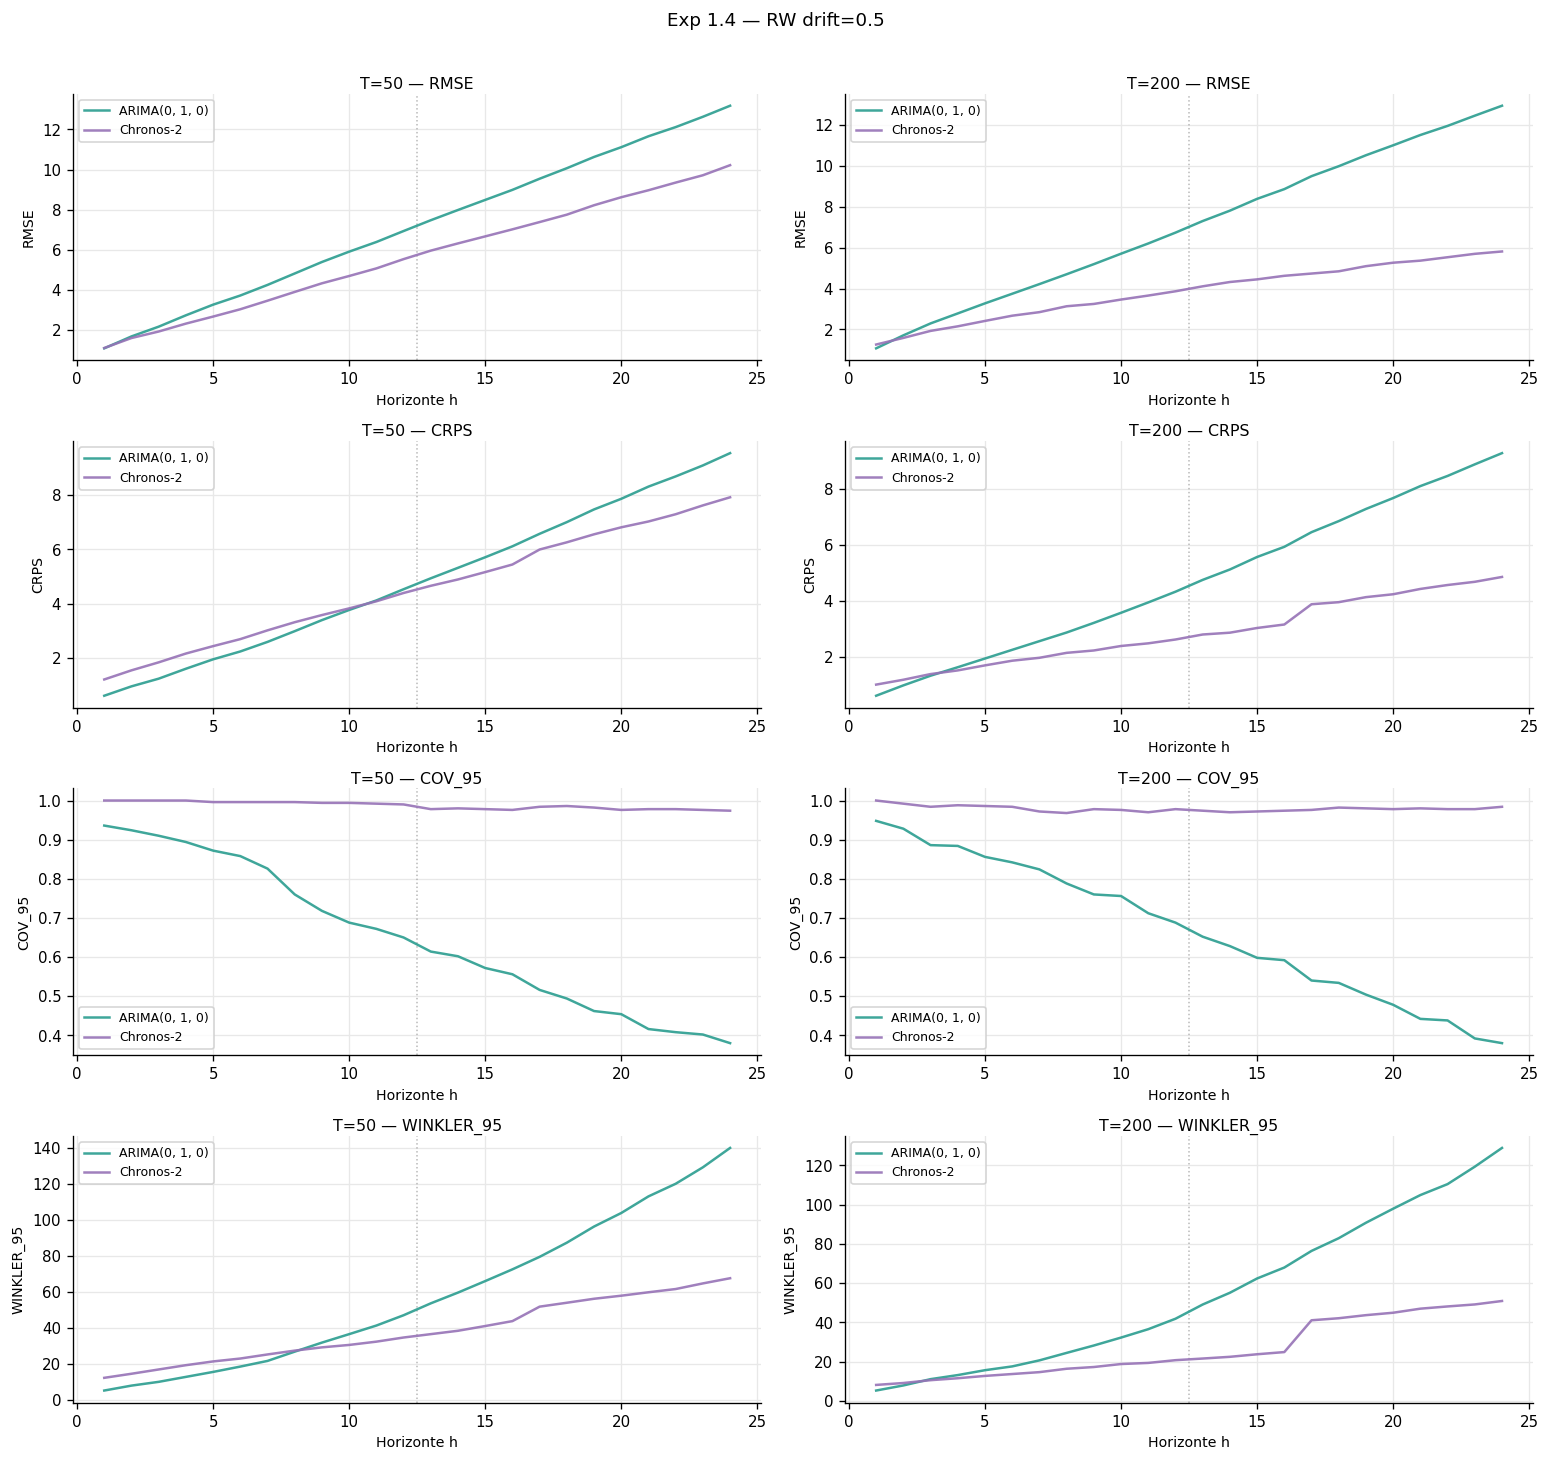

In [35]:
res_1_4 = load_uni('1.4')
styled_table(res_1_4, title='Exp 1.4 — RW drift=0.5')
_ = plot_metrics_horizon(res_1_4, title='Exp 1.4 — RW drift=0.5')


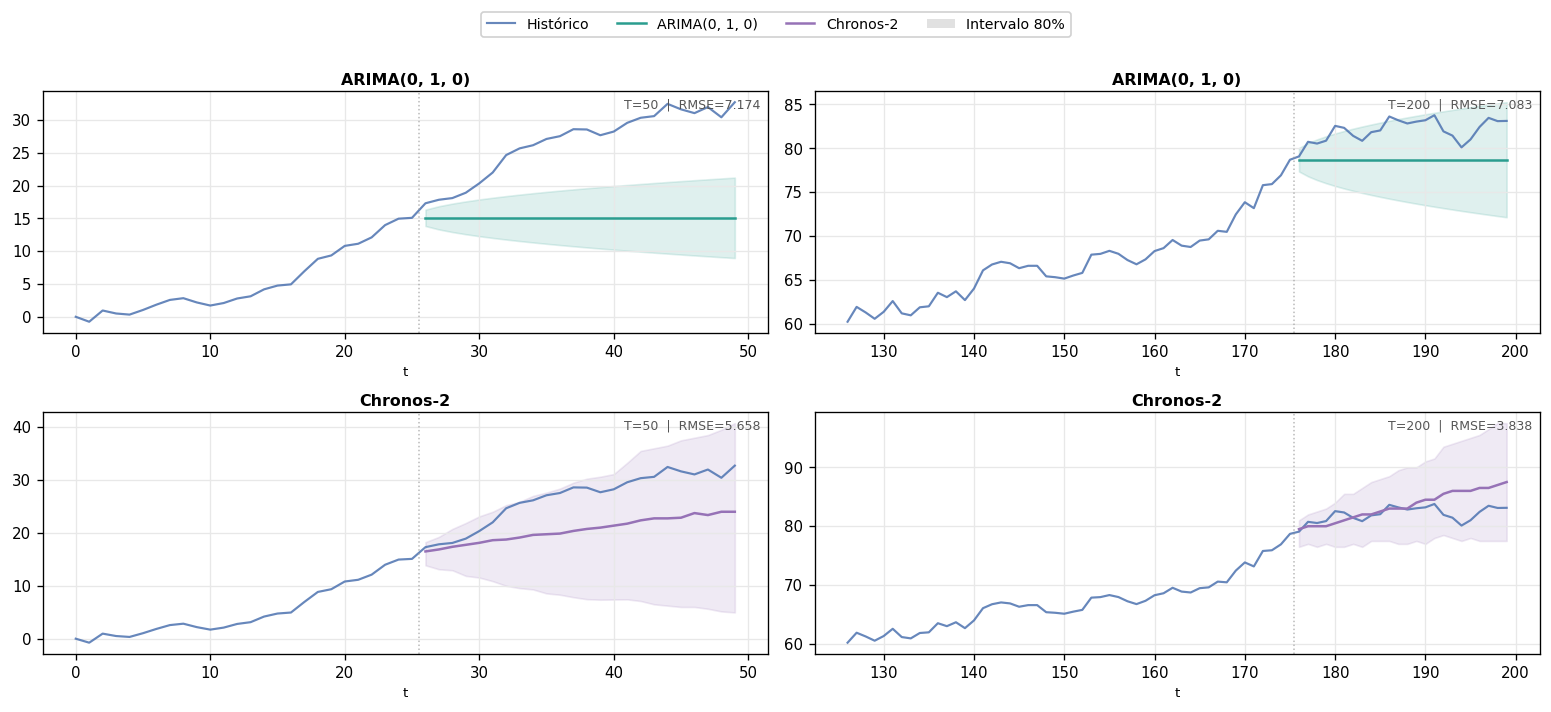

In [36]:
make_models_1_4 = lambda T: [ARIMAModel((0,1,0)), chronos_uni]
_ = plot_rep_uni(dgp_1_4, make_models_1_4, {'drift': 0.5},
             title='Exp 1.4 — RW drift=0.5 (ARIMA sin constante)', mc_results=res_1_4)


## Exp 1.7 — Seasonal I(1)×I(1)₁₂ *(limitación estructural de Chronos)*

**DGP:** $(1-L)(1-L^{12})\,Y_t = \varepsilon_t$

**El peor resultado de Chronos en el bloque.** SARIMA domina +40–45% en RMSE, brecha **estable** con T (no se cierra con más contexto). La doble integración estacional es la limitación estructural más clara del foundation model: no maneja no-estacionariedad de largo alcance en dos dimensiones.

**Hipótesis:** SARIMA domina todas las métricas; Chronos no mejora con T=200.

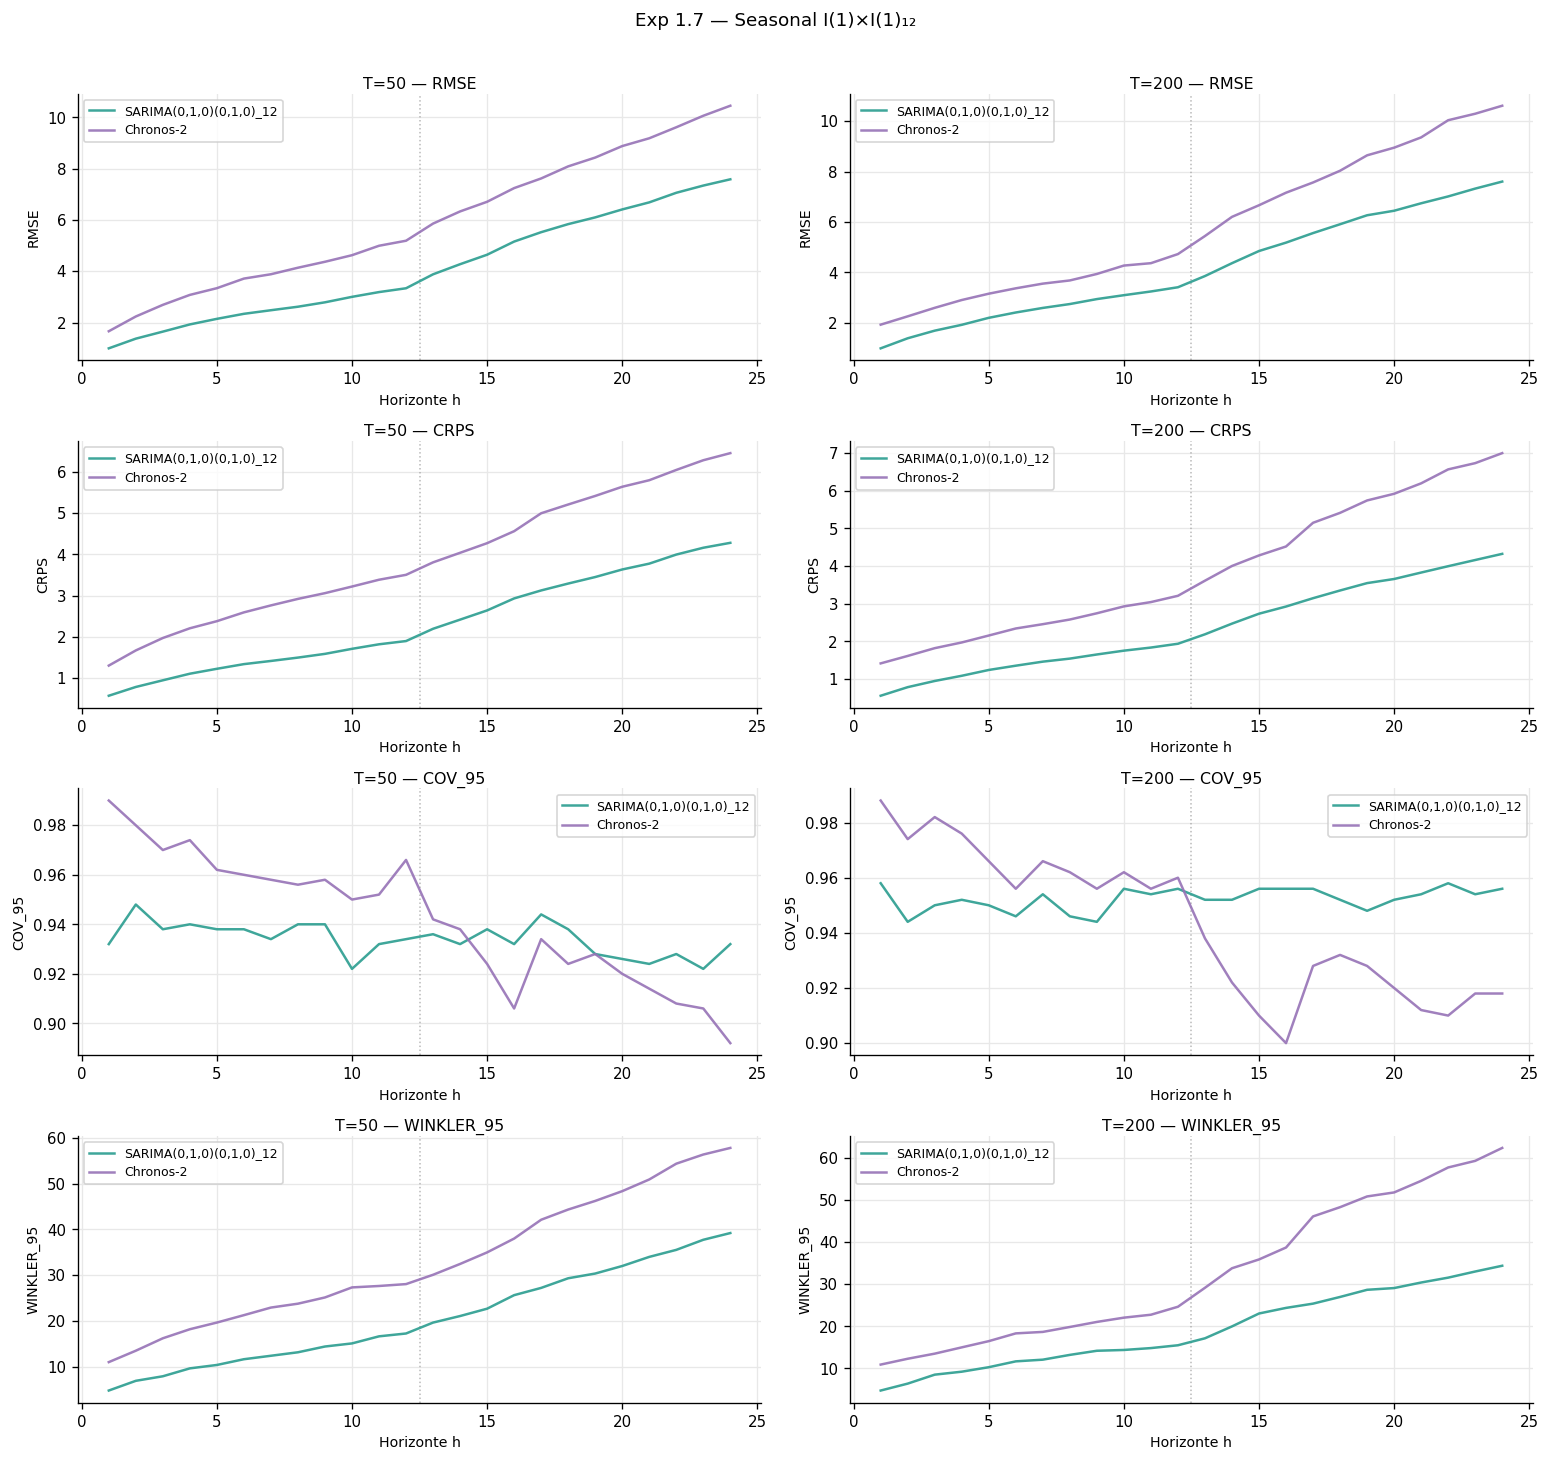

In [37]:
res_1_7 = load_uni('1.7')
styled_table(res_1_7, title='Exp 1.7 — Seasonal I(1)×I(1)₁₂')
_ = plot_metrics_horizon(res_1_7, title='Exp 1.7 — Seasonal I(1)×I(1)₁₂')


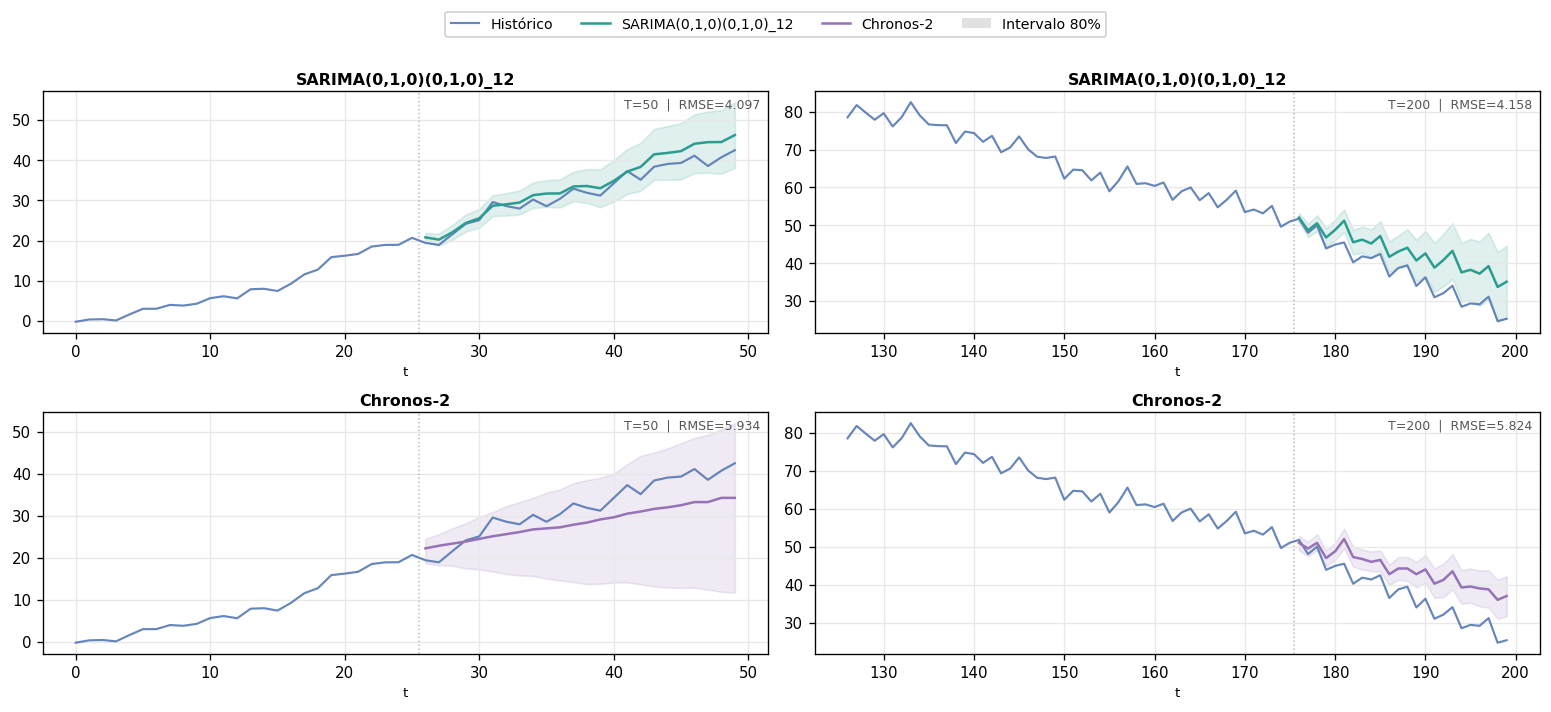

In [38]:
make_models_1_7 = lambda T: [
    SARIMAModel((0,1,0), (0,1,0,12)),
    chronos_uni,
]
_ = plot_rep_uni(dgp_1_7, make_models_1_7, {'s': 12, 'integrated': True},
             title='Exp 1.7 — Seasonal I(1)×I(1)₁₂', mc_results=res_1_7)


## Exp 1.10 — AR(1)–GARCH(1,1), α+β=0.9 *(RMSE ≠ CRPS)*

**DGP:** $Y_t = 0.3\,Y_{t-1} + \varepsilon_t, \quad \sigma_t^2 = 0.1 + 0.1\,\varepsilon_{t-1}^2 + 0.8\,\sigma_{t-1}^2$

**Representa el bloque GARCH (1.9–1.12).** A T=200: paridad casi perfecta en RMSE (~1%) pero la brecha en CRPS persiste (~23%). Chronos produce distribuciones predictivas más anchas de lo necesario aun cuando el error puntual converge. La dinámica GARCH afecta la varianza condicional, no la media.

**Hipótesis:** Empate en RMSE a T=200; ventaja persistente del modelo clásico en CRPS y calibración.

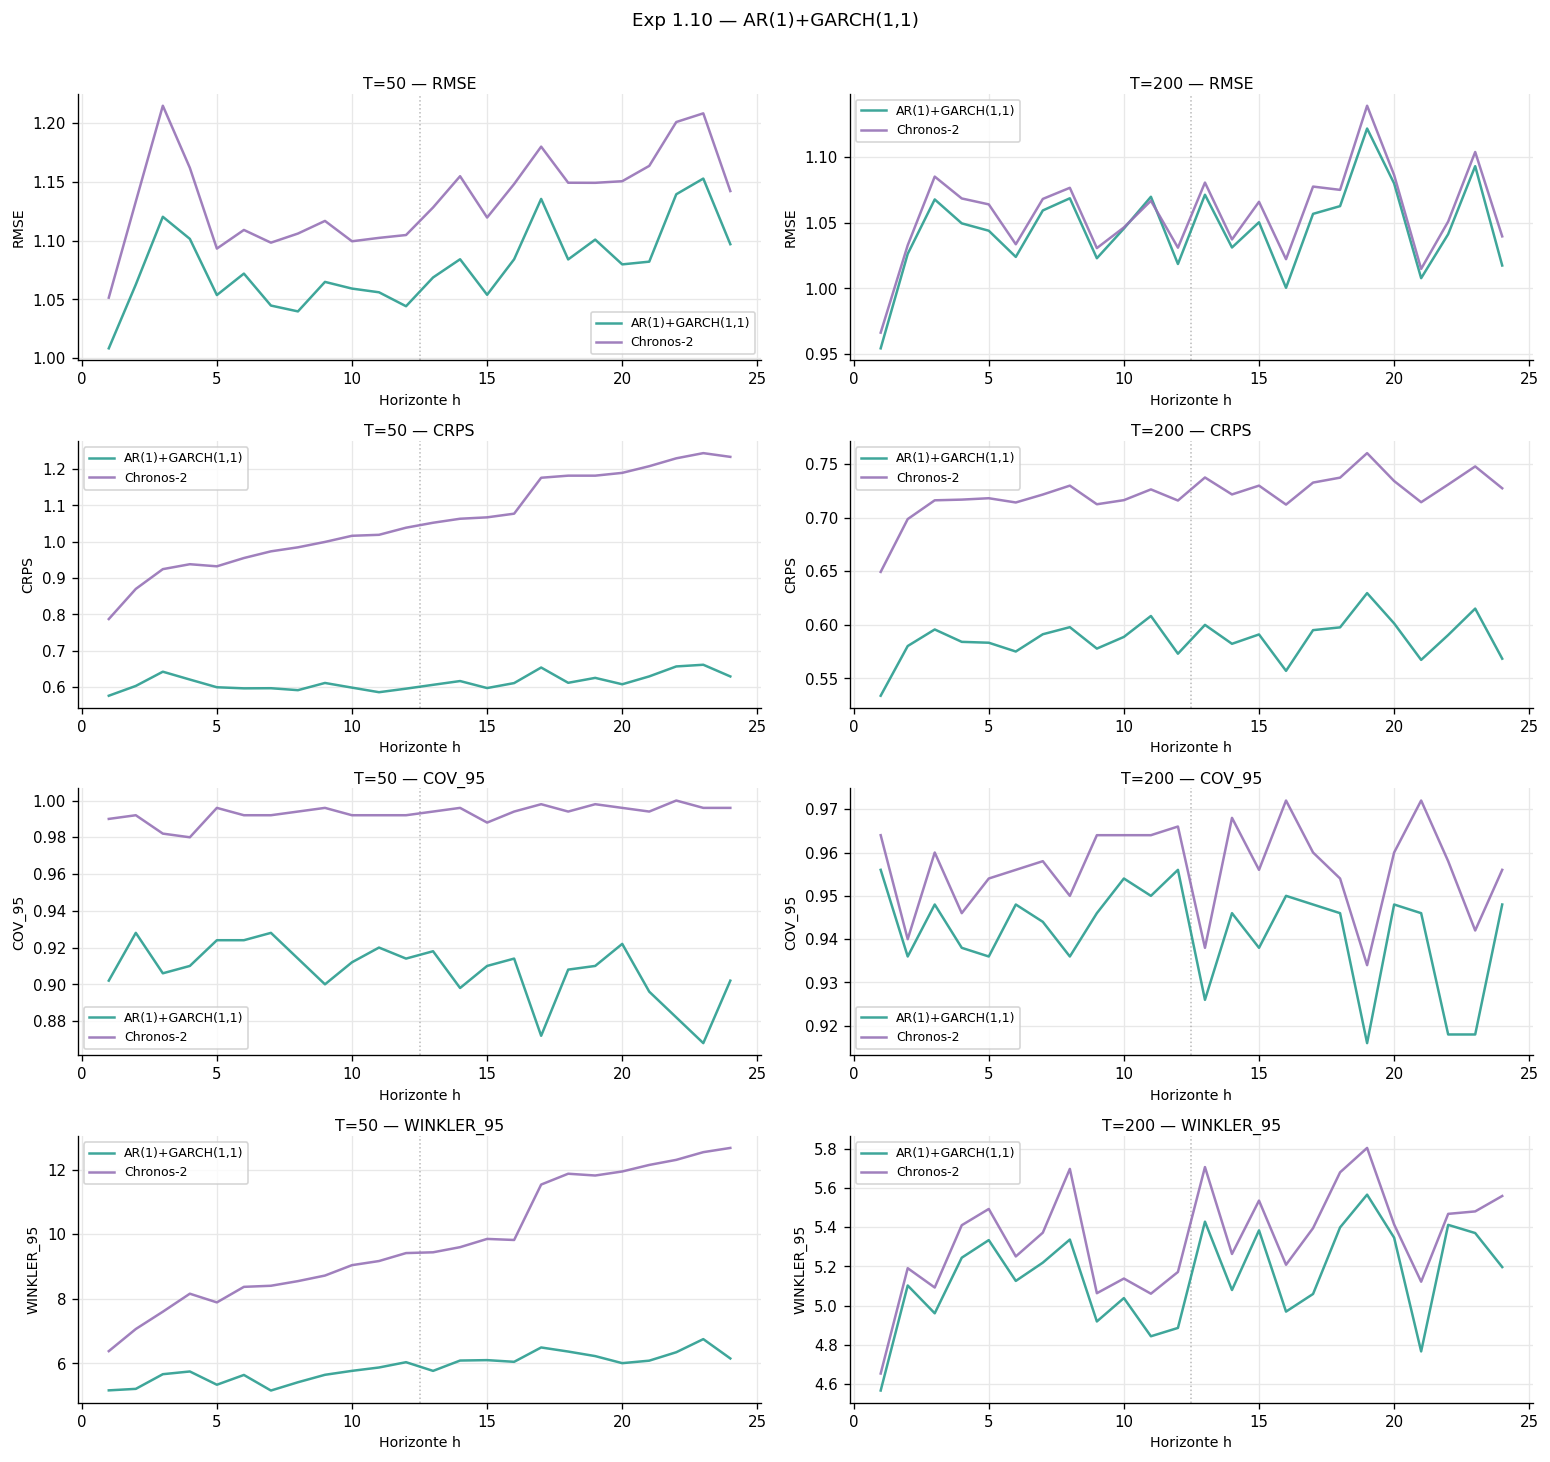

In [39]:
res_1_10 = load_uni('1.10')
styled_table(res_1_10, title='Exp 1.10 — AR(1)+GARCH(1,1)')
_ = plot_metrics_horizon(res_1_10, title='Exp 1.10 — AR(1)+GARCH(1,1)')


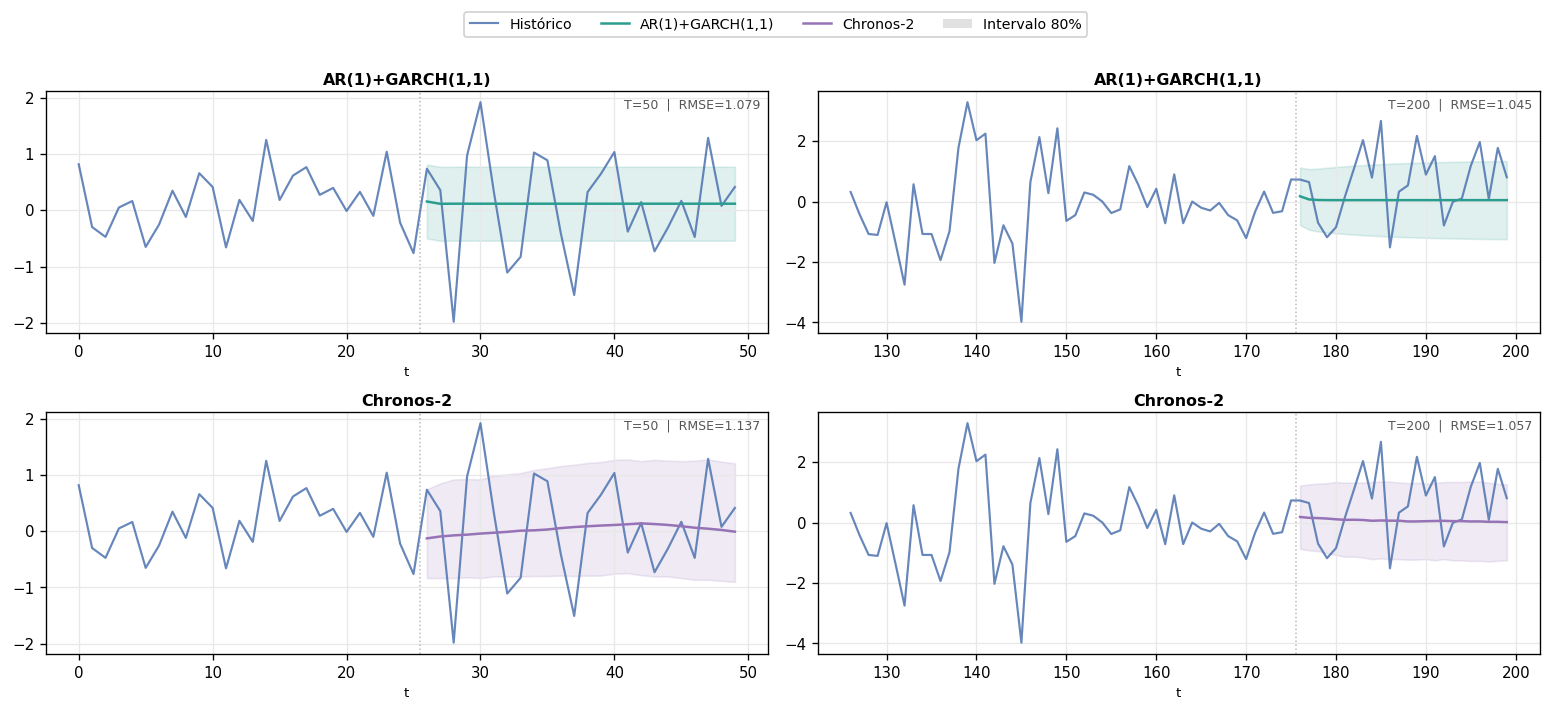

In [40]:
make_models_1_10 = lambda T: [ARGARCHModel(), chronos_uni]
_ = plot_rep_uni(dgp_1_10, make_models_1_10,
             {'phi': 0.3, 'omega': 0.1, 'alpha': 0.1, 'beta': 0.8},
             title='Exp 1.10 — AR(1)+GARCH(1,1)', mc_results=res_1_10)


## Exp 1.19 — Tendencia lineal / Theta *(colapso catastrófico del modelo clásico)*

**DGP:** $Y_t = 0.1\,t + \varepsilon_t, \quad \varepsilon_t \sim \mathcal{N}(0,1)$

**La mayor inversión del bloque.** A T=50: Theta domina (26% mejor RMSE). A T=200: **Theta colapsa** — RMSE=7.89, bias=−7.63, cov_95=0.640. Chronos domina por factor 7.7× en RMSE. El mecanismo: el optimizador de Theta converge a la media histórica (~10) ignorando que el nivel actual es ~20. Complementa el mensaje de Exp 1.4: los modelos clásicos también pueden fallar estructuralmente.

**Hipótesis:** Inversión dramática entre T=50 y T=200. Chronos aprende el slope con suficiente historia.

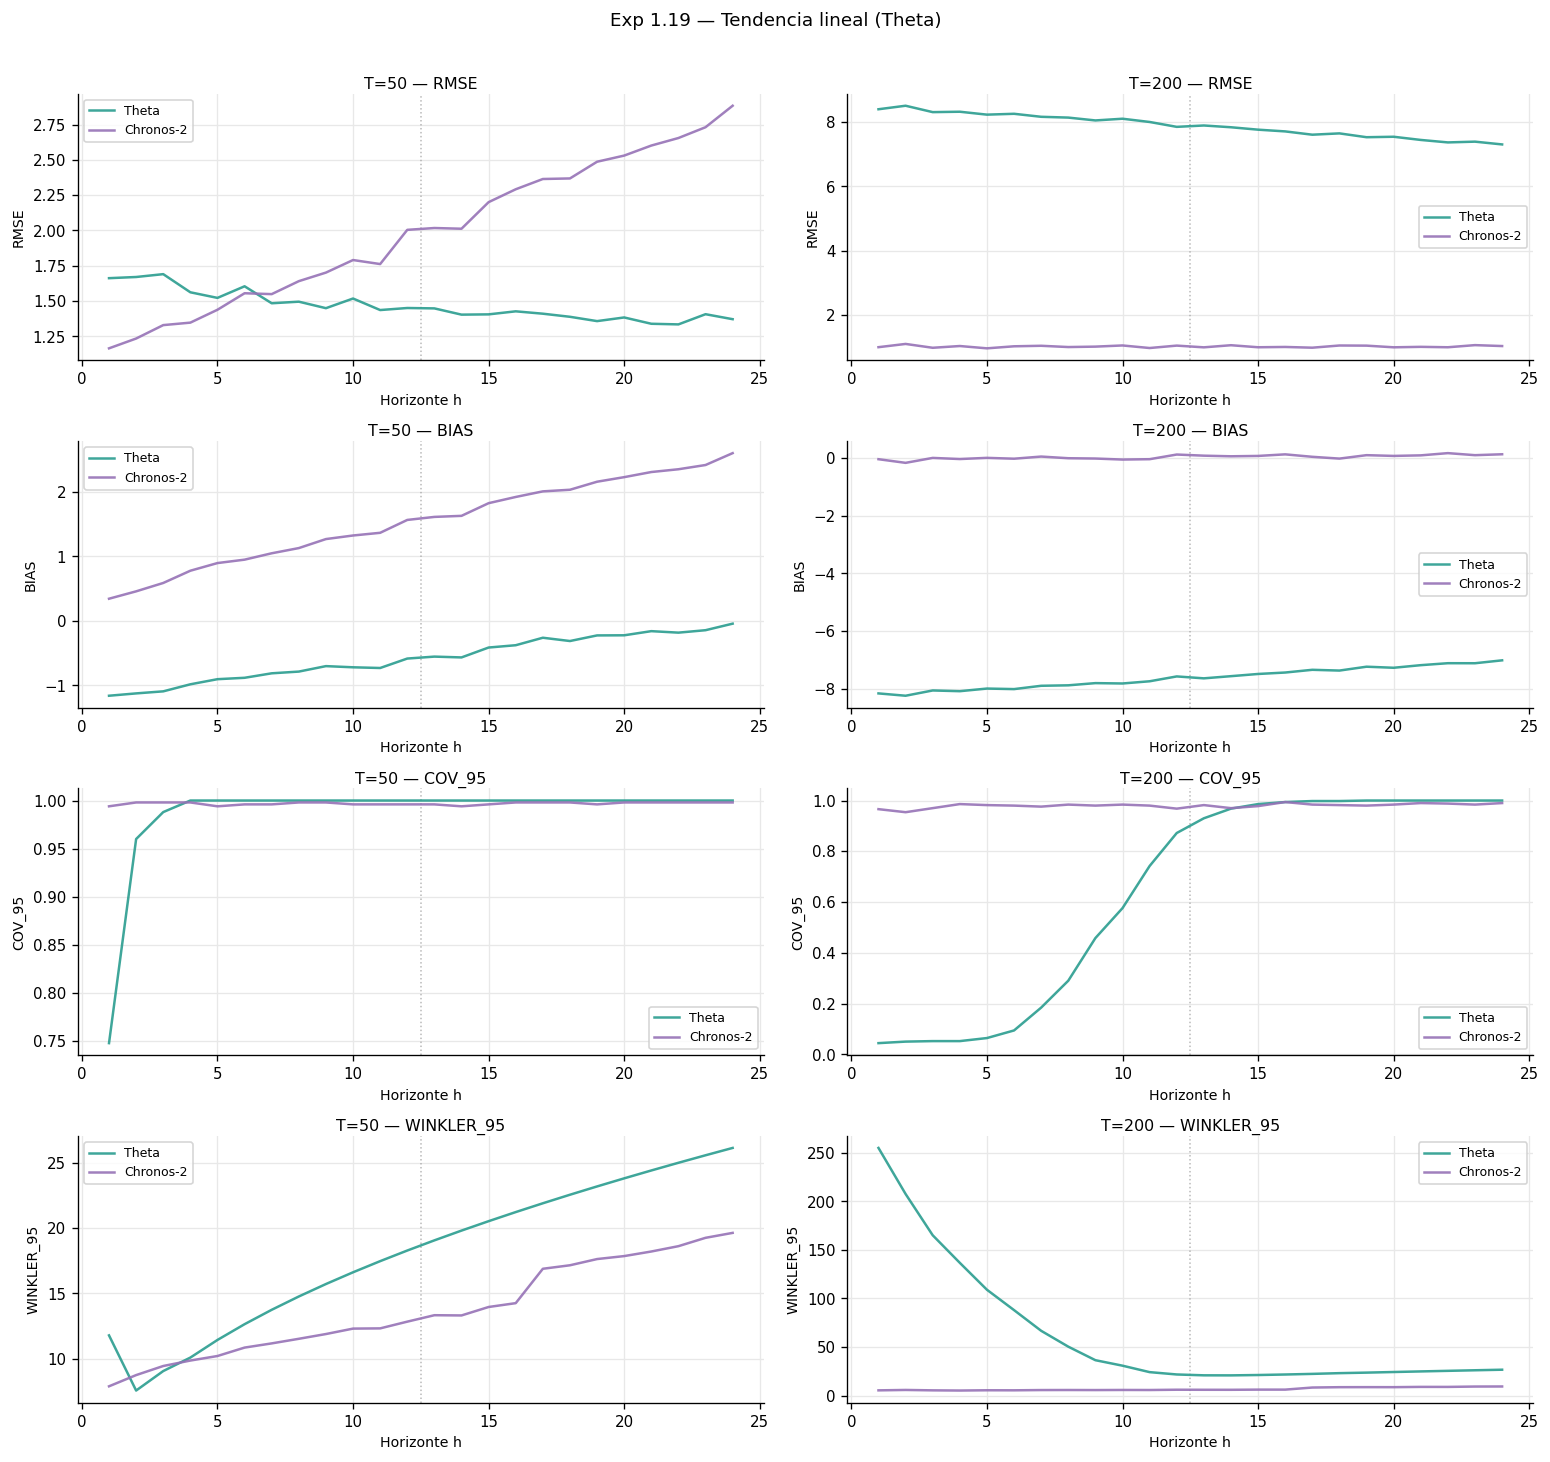

In [41]:
res_1_19 = load_uni('1.19')
styled_table(res_1_19, title='Exp 1.19 — Tendencia lineal (Theta)')
_ = plot_metrics_horizon(res_1_19, metrics=('rmse','bias','cov_95','winkler_95'),
                     title='Exp 1.19 — Tendencia lineal (Theta)')


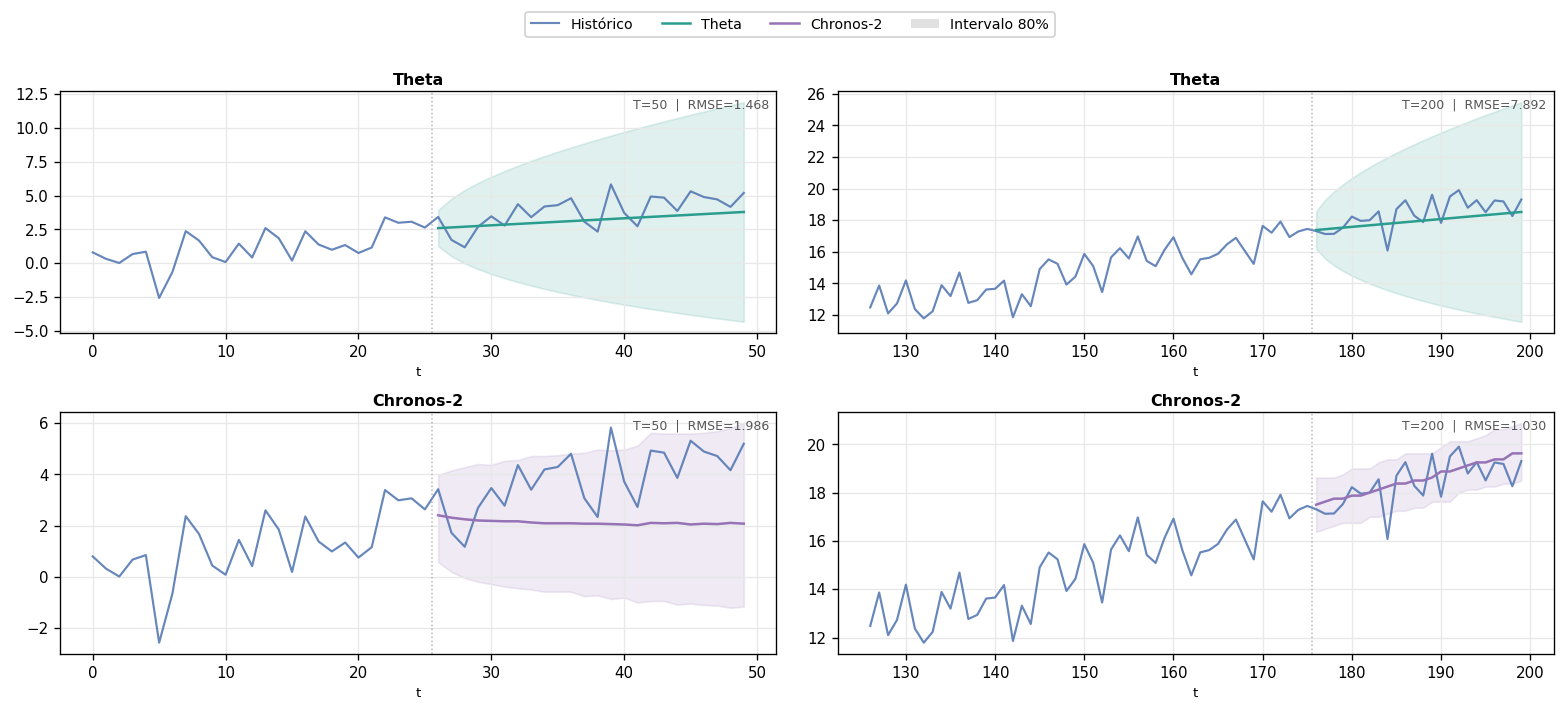

In [42]:
make_models_1_19 = lambda T: [ThetaModel(), chronos_uni]
_ = plot_rep_uni(dgp_1_19, make_models_1_19,
             {'intercept': 0.0, 'trend_coeff': 0.1, 'phi': 0.0},
             title='Exp 1.19 — Tendencia lineal (Theta)', mc_results=res_1_19)


---

# Experimentos Multivariados

Seleccionados: **2.1** (baseline k=2) · **2.5** (paridad RMSE k=5) · **2.7** (VECM cointegrado)  

Métricas reportadas como promedio sobre las k variables y los H=24 horizontes.  
Gráficas de simulación muestran la variable Y₀.

## Exp 2.1 — VAR(1) bivariado, baja interdependencia (k=2)

**DGP:** $Y_t = A_1 Y_{t-1} + \varepsilon_t, \quad A_1 = \begin{pmatrix}0.5&0.1\\0.1&0.5\end{pmatrix}, \quad \Sigma = \begin{pmatrix}1.0&0.3\\0.3&1.0\end{pmatrix}$

**Caso base multivariado.** VAR domina en RMSE (+7% T=50, +1% T=200) y CRPS (+73%/+23%). Chronos-joint y Chronos-ind son prácticamente iguales: con baja interdependencia, la API conjunta no aporta sobre k=2 forecasts independientes.

**Hipótesis:** VAR domina en todas las métricas; Chronos-joint ≈ Chronos-ind.

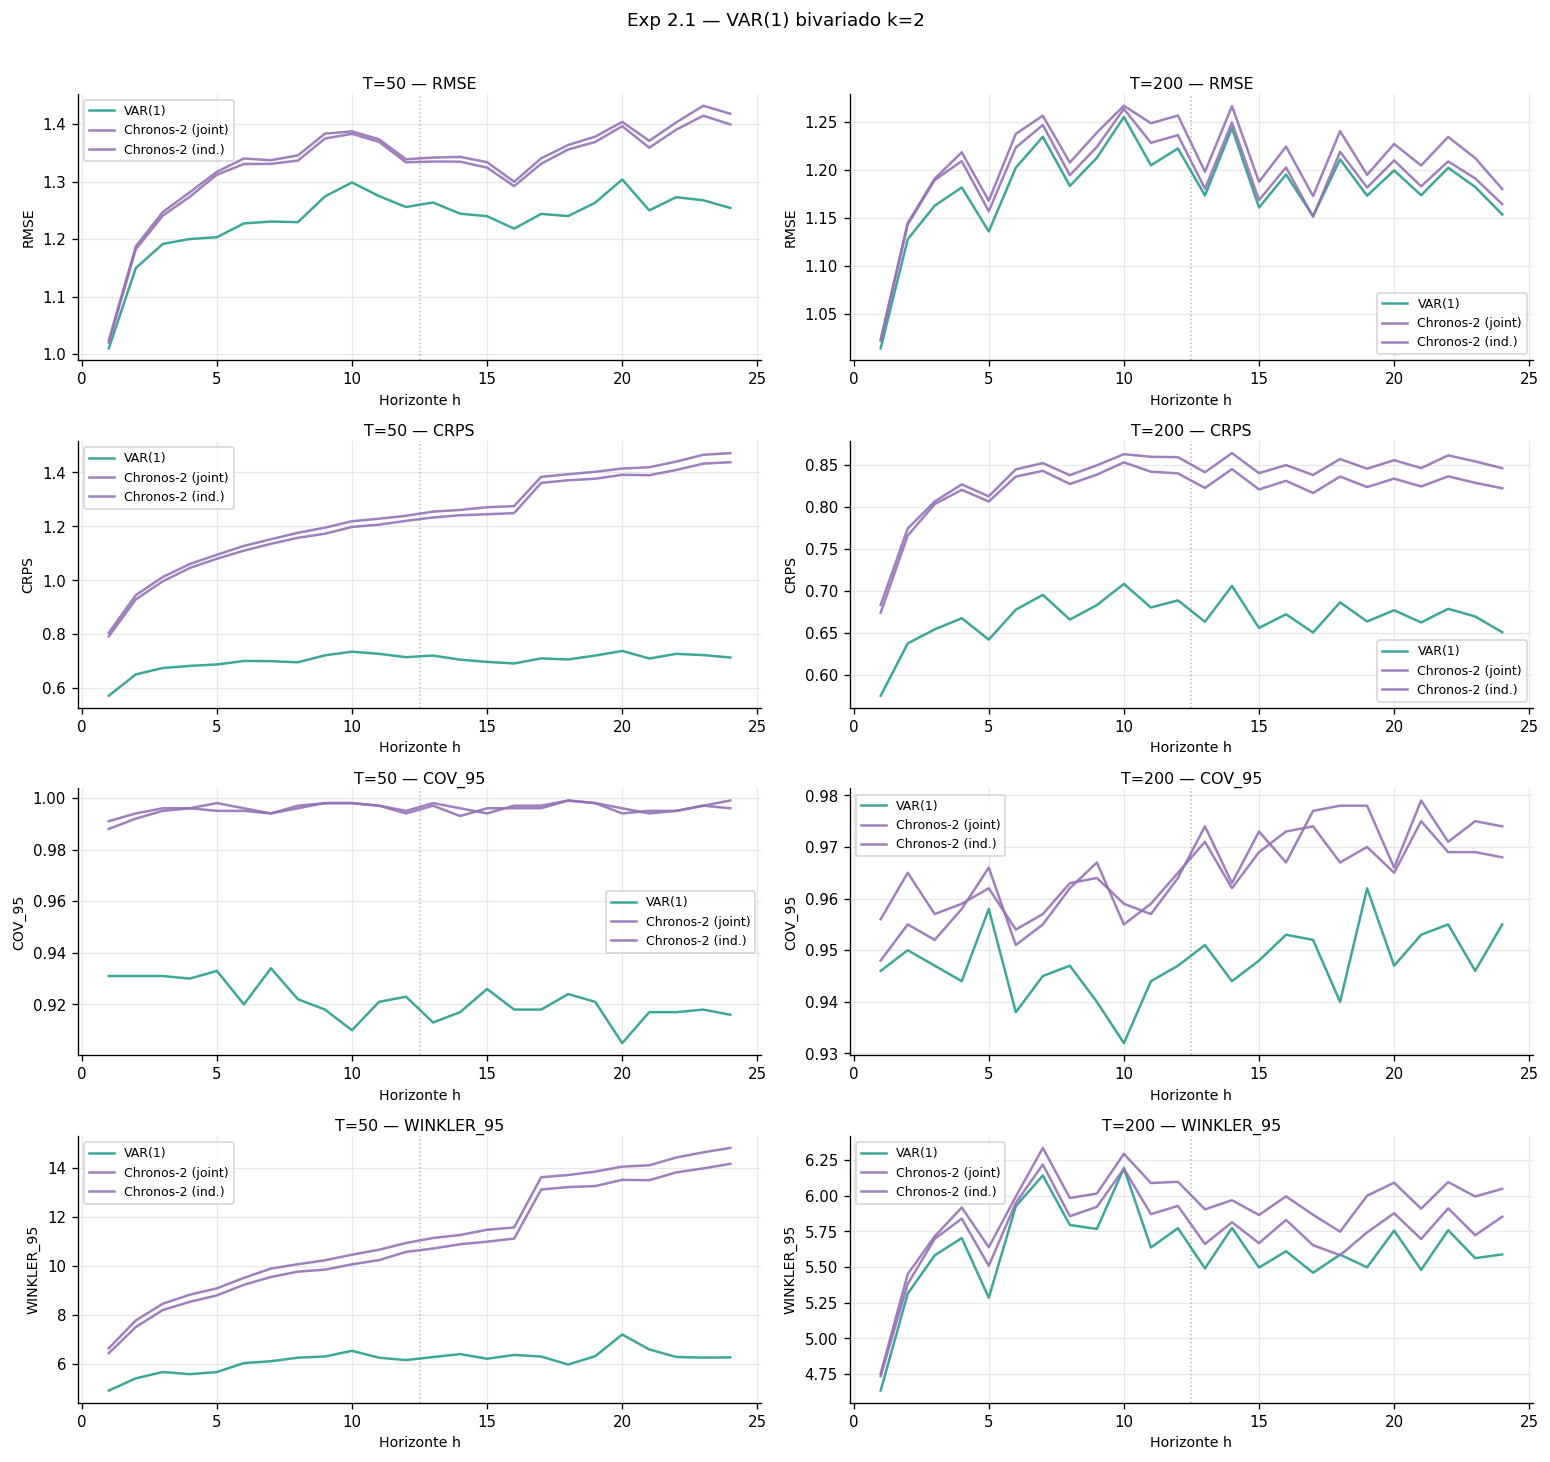

In [43]:
res_2_1 = load_mv('2.1')
styled_table(res_2_1, title='Exp 2.1 — VAR(1) bivariado k=2', is_mv=True)
_ = plot_metrics_horizon(res_2_1, title='Exp 2.1 — VAR(1) bivariado k=2', is_mv=True)


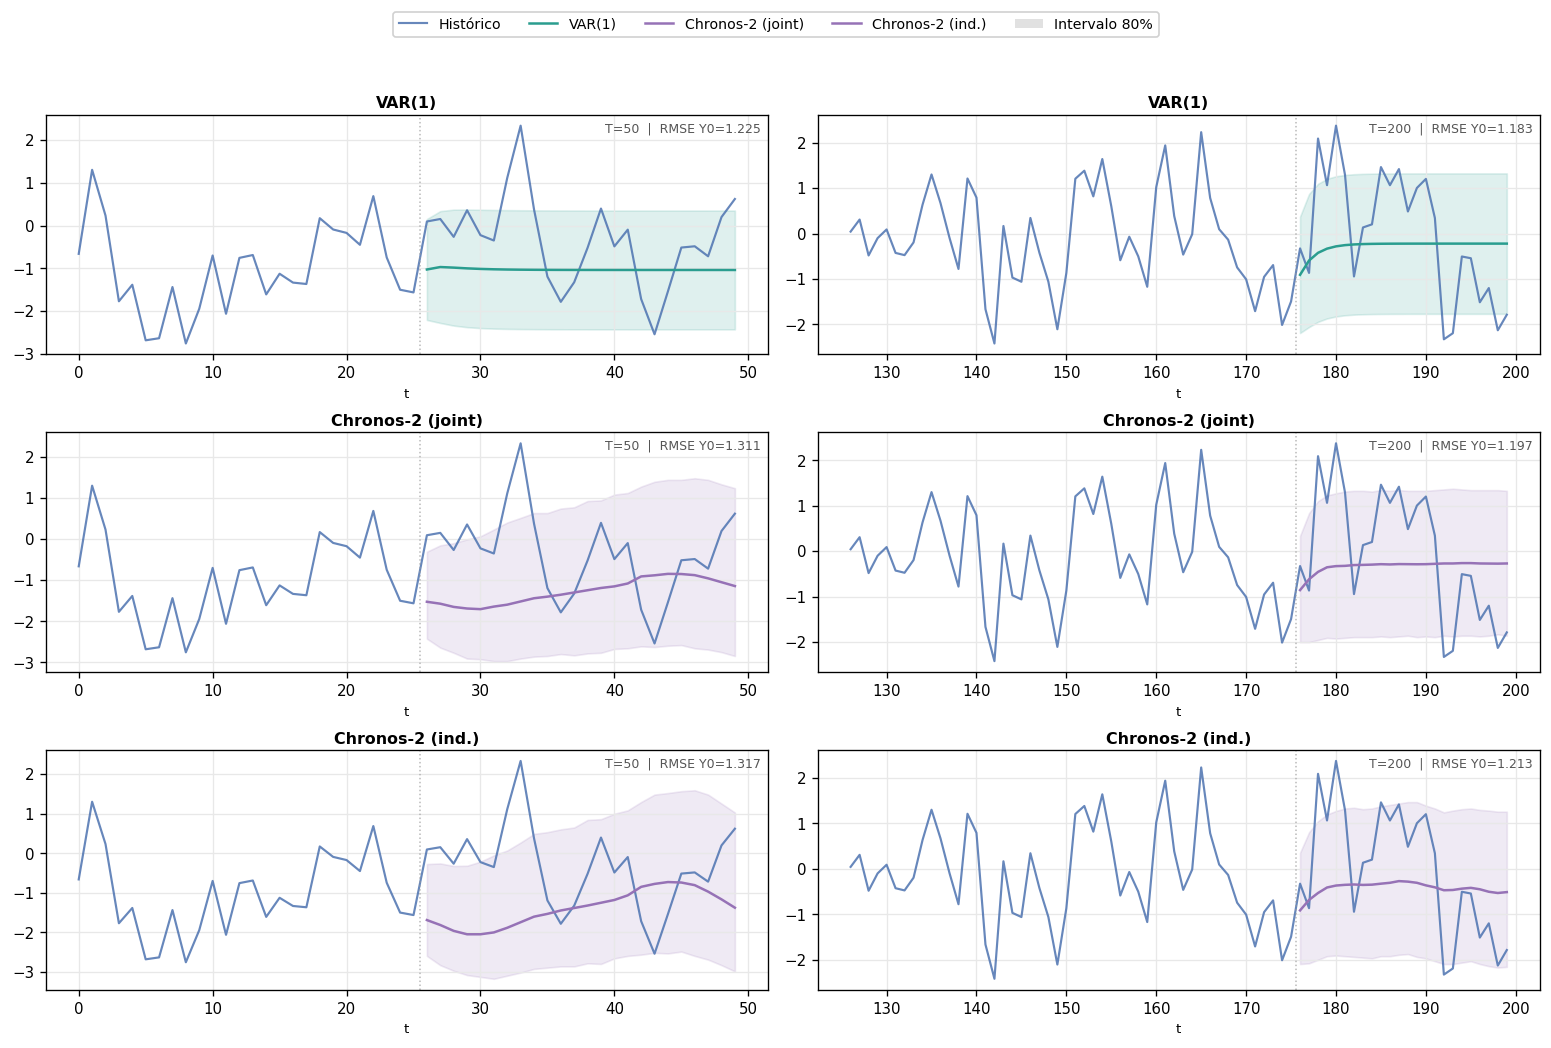

In [44]:
make_models_2_1 = lambda T: [VARModel(1), chronos_mv, chronos_mv_ind]
_ = plot_rep_mv(dgp_2_1, make_models_2_1, title='Exp 2.1 — VAR(1) k=2', mc_results=res_2_1)


## Exp 2.5 — VAR(1) pentavariado, k=5 *(paridad en RMSE)*

**DGP:** $Y_t = A_1 Y_{t-1} + \varepsilon_t$, $k=5$, $A_1$ tridiagonal (diagonal 0.3, off-diagonal 0.05), $\Sigma$ tridiagonal (diagonal 1.0, off-diagonal 0.2)

**El resultado más sorprendente del bloque.** RMSE en paridad a **ambos** T (+0.3% T=50, +0.5% T=200): la maldición de dimensionalidad no se manifiesta en RMSE con coeficientes cruzados débiles. Sin embargo, la brecha en CRPS persiste (+40% T=50, +21% T=200): incluso cuando el nivel de error converge, Chronos produce distribuciones más anchas.

**Hipótesis:** Empate RMSE; VAR con ventaja sistemática en CRPS.

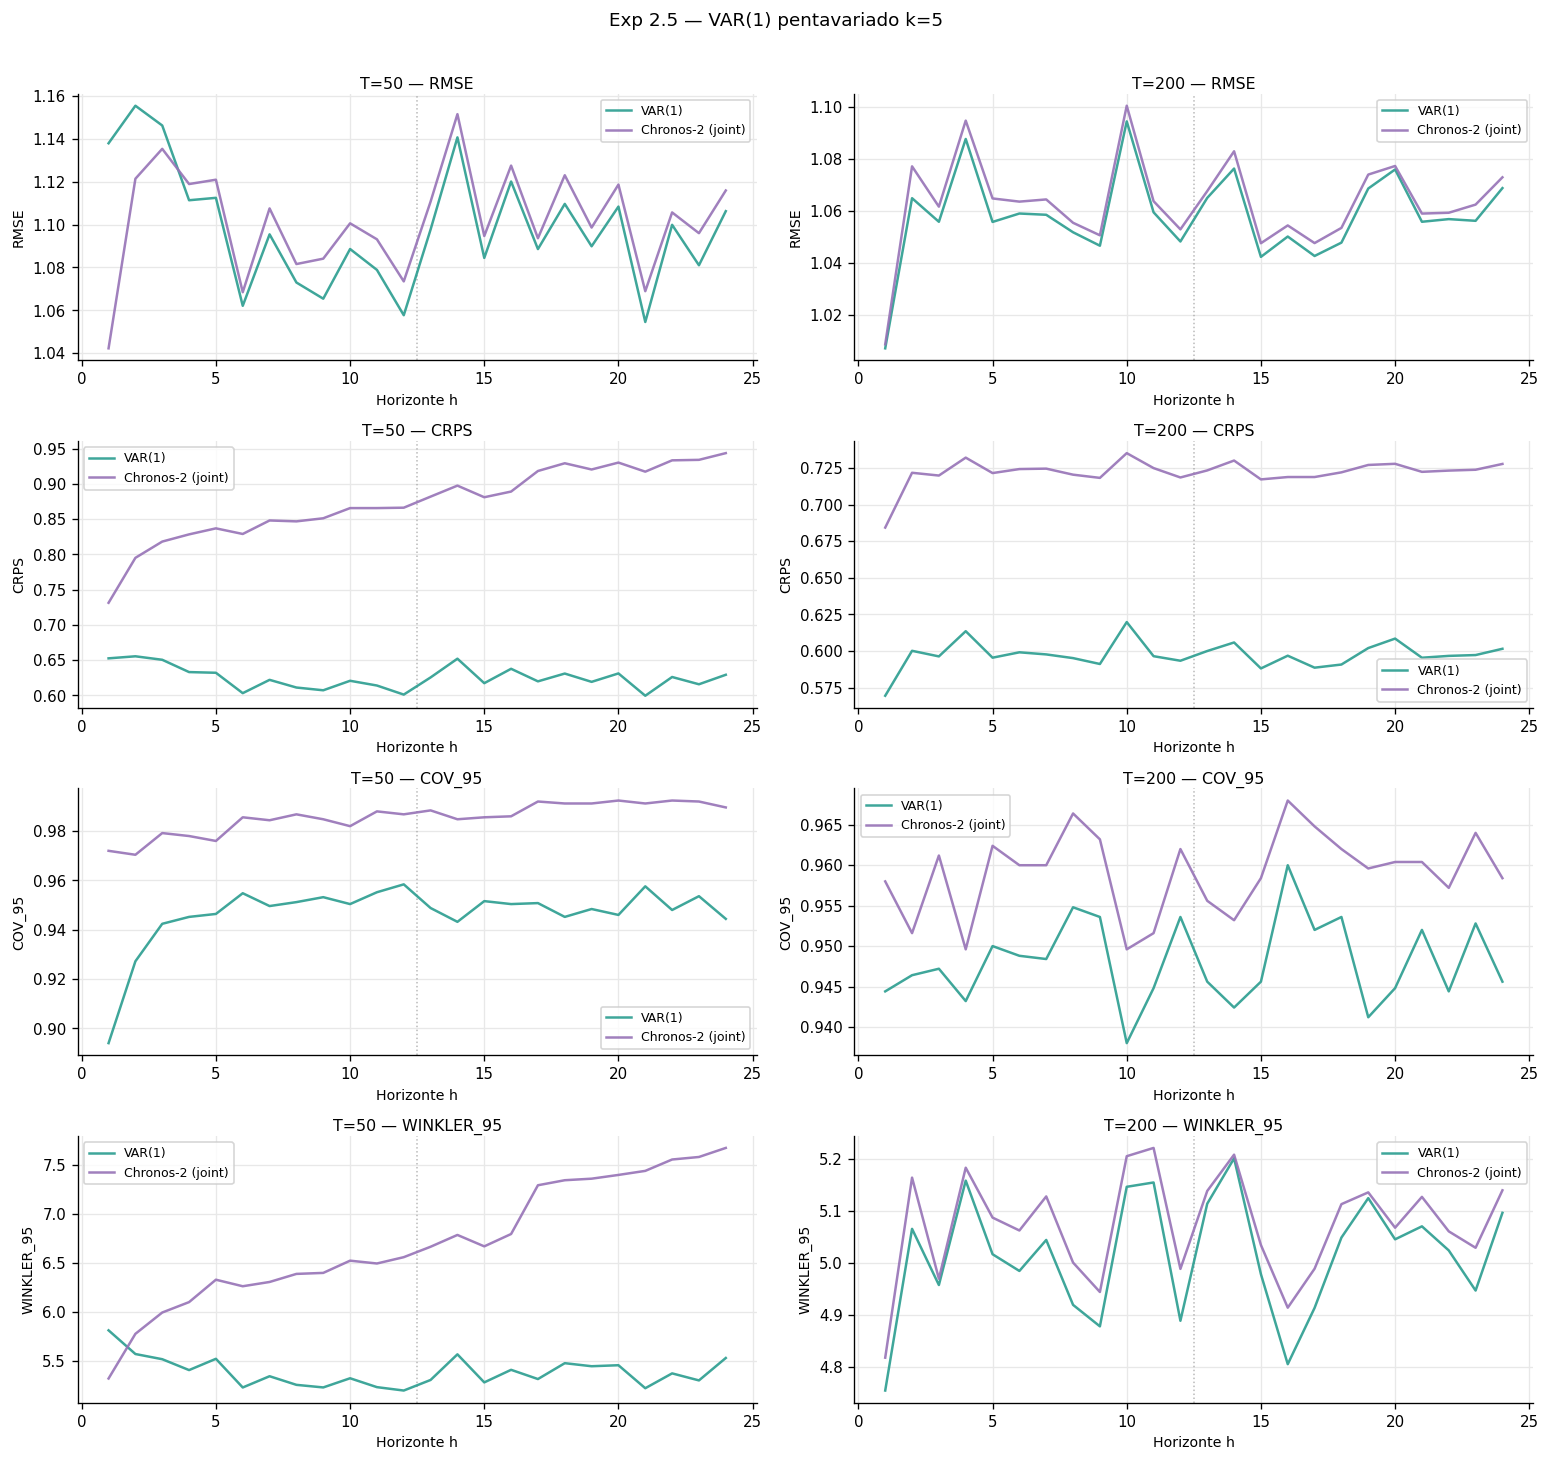

In [45]:
res_2_5 = load_mv('2.5')
styled_table(res_2_5, title='Exp 2.5 — VAR(1) pentavariado k=5', is_mv=True)
_ = plot_metrics_horizon(res_2_5, title='Exp 2.5 — VAR(1) pentavariado k=5', is_mv=True)


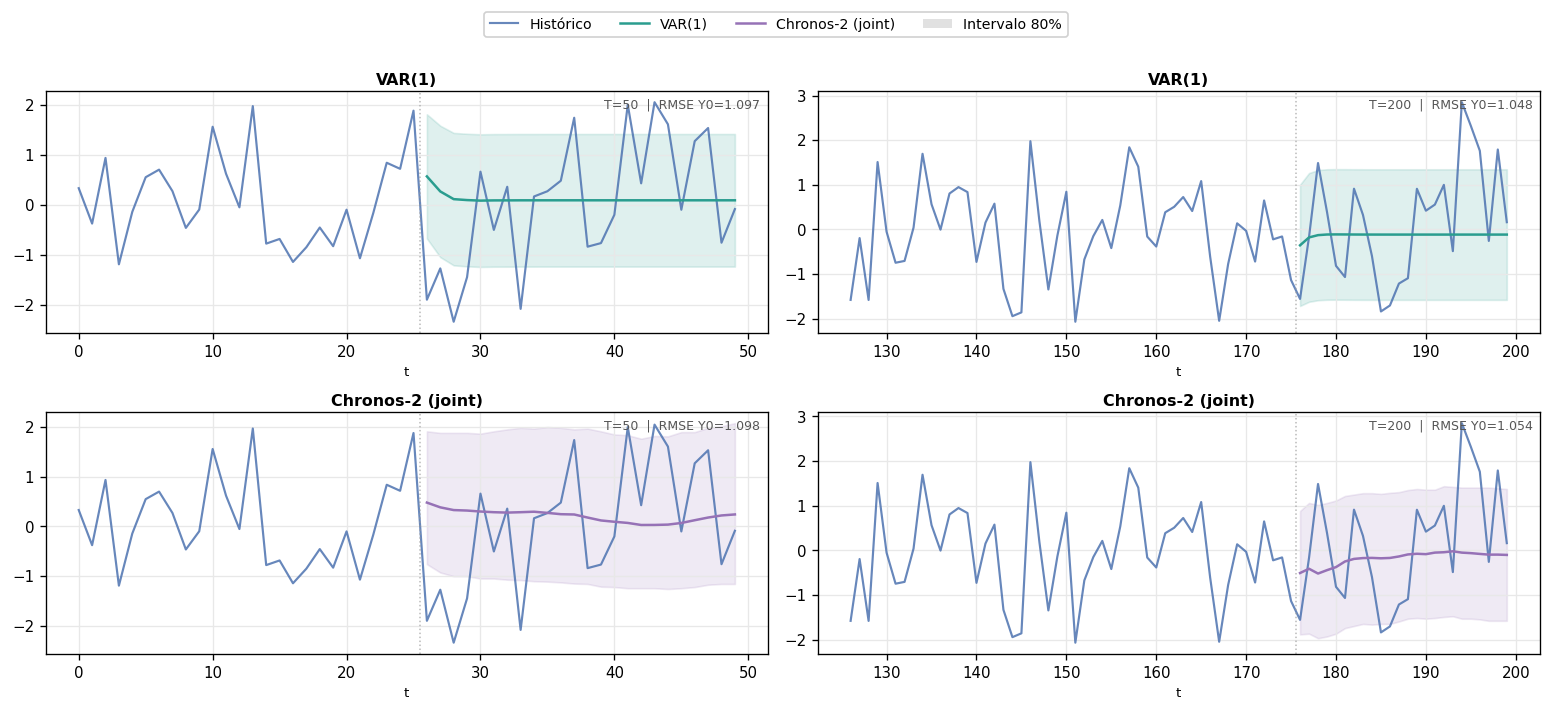

In [46]:
make_models_2_5 = lambda T: [VARModel(1), chronos_mv]
_ = plot_rep_mv(dgp_2_5, make_models_2_5, title='Exp 2.5 — VAR(1) k=5', mc_results=res_2_5)


## Exp 2.7 — VECM bivariado cointegrado (k=2, rango 1)

**DGP:** $(1-L)Y_t = \alpha(\beta' Y_{t-1}) + \Gamma_1 (1-L)Y_{t-1} + \varepsilon_t$, $\beta=(1,-1)'$, $\alpha=(-0.4,0.2)'$

**El experimento más dramático del bloque.** VAR(1) colapsa a T=50 (+76% RMSE): aplica VAR en niveles a datos I(1) cointegrados sin restricción de rango → regresión espuria. A T=200, VAR se recupera parcialmente (+6%). Chronos-joint supera a VAR(1) en RMSE a T=200 ($-0.8\%$): **única victoria de Chronos en RMSE** en el bloque, posible por la misspecificación del benchmark. VECM correctamente especificado domina en CRPS en ambos T.

**Replica la lección de Exp 1.4:** Chronos > modelo clásico *misspecificado*, pero no > modelo *correctamente especificado*.

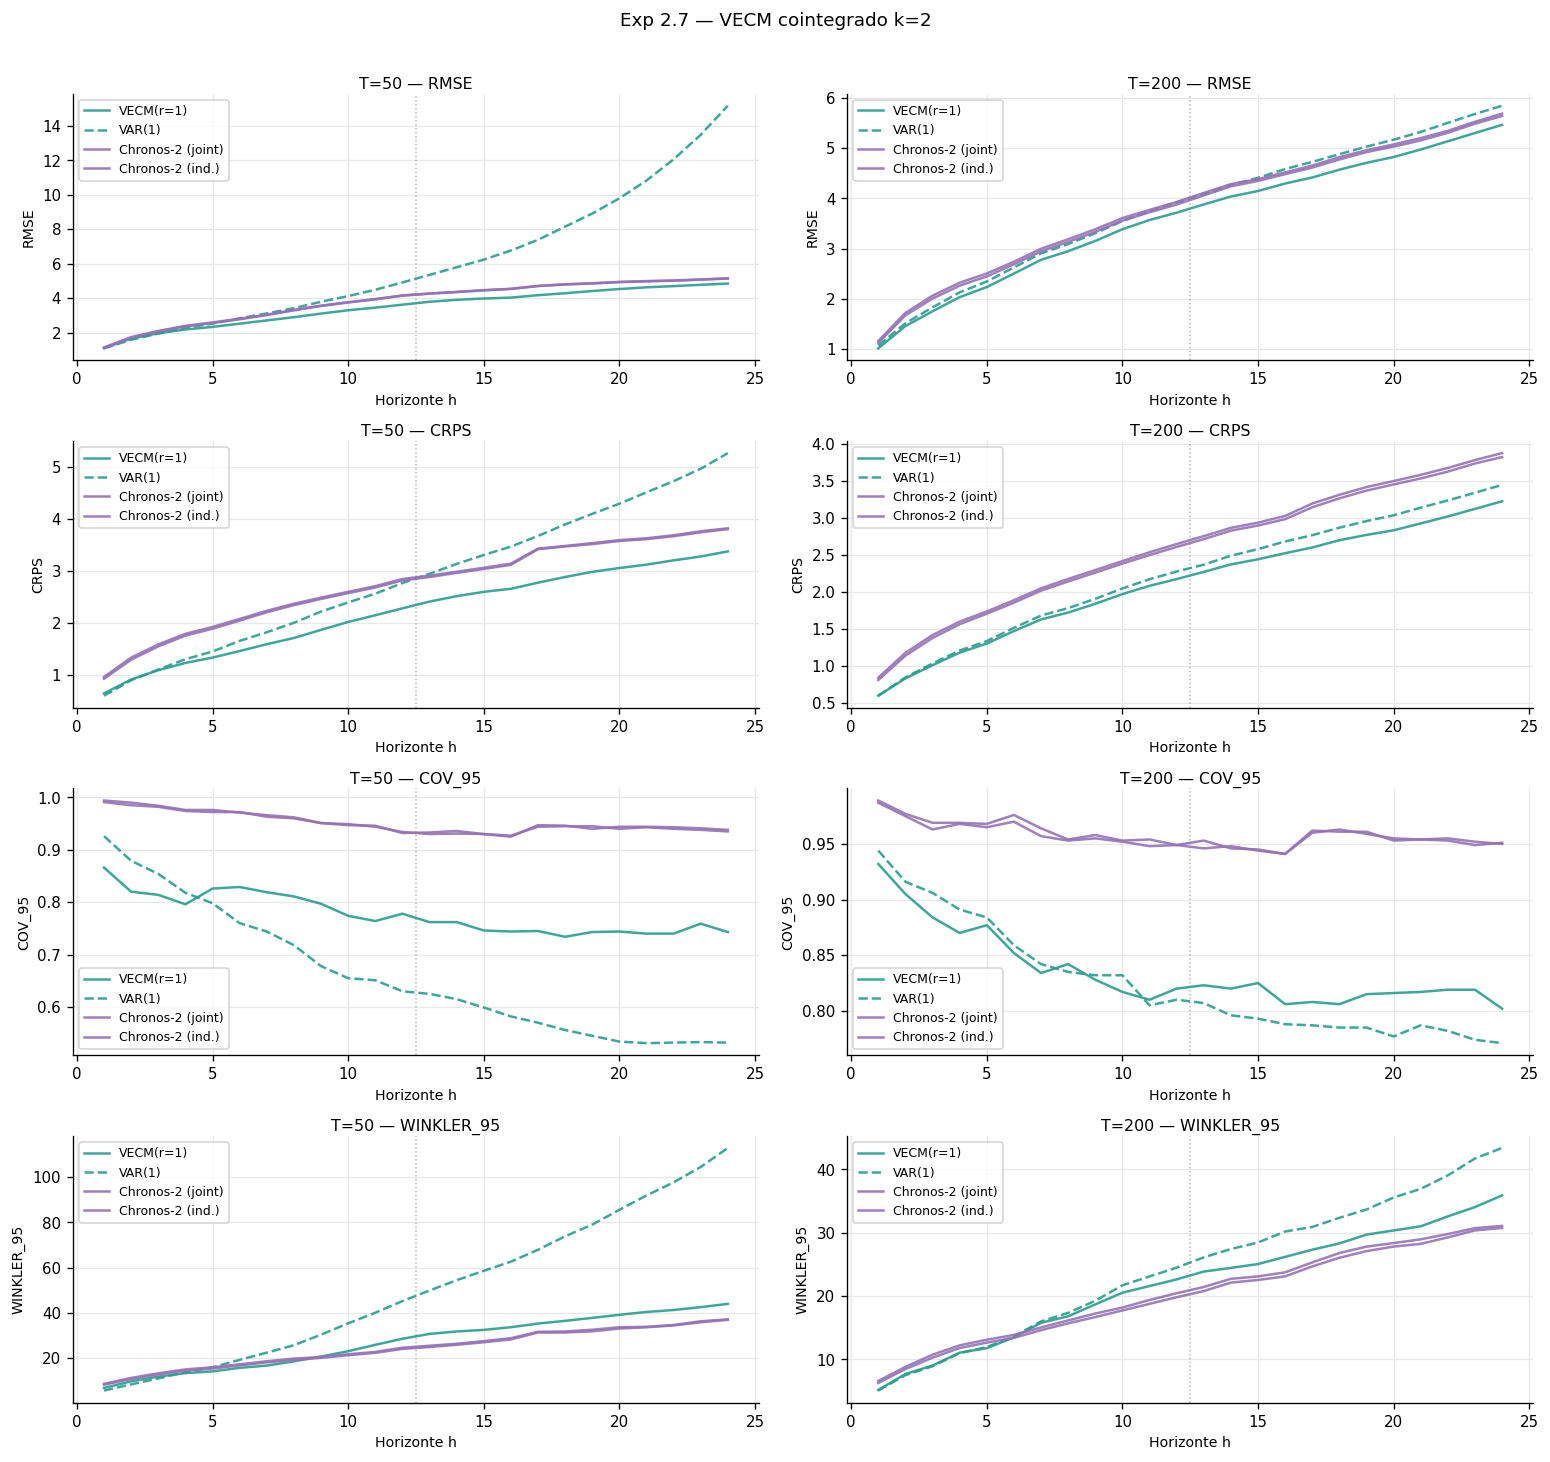

In [47]:
res_2_7 = load_mv('2.7')
styled_table(res_2_7, title='Exp 2.7 — VECM cointegrado k=2', is_mv=True)
_ = plot_metrics_horizon(res_2_7, title='Exp 2.7 — VECM cointegrado k=2', is_mv=True)


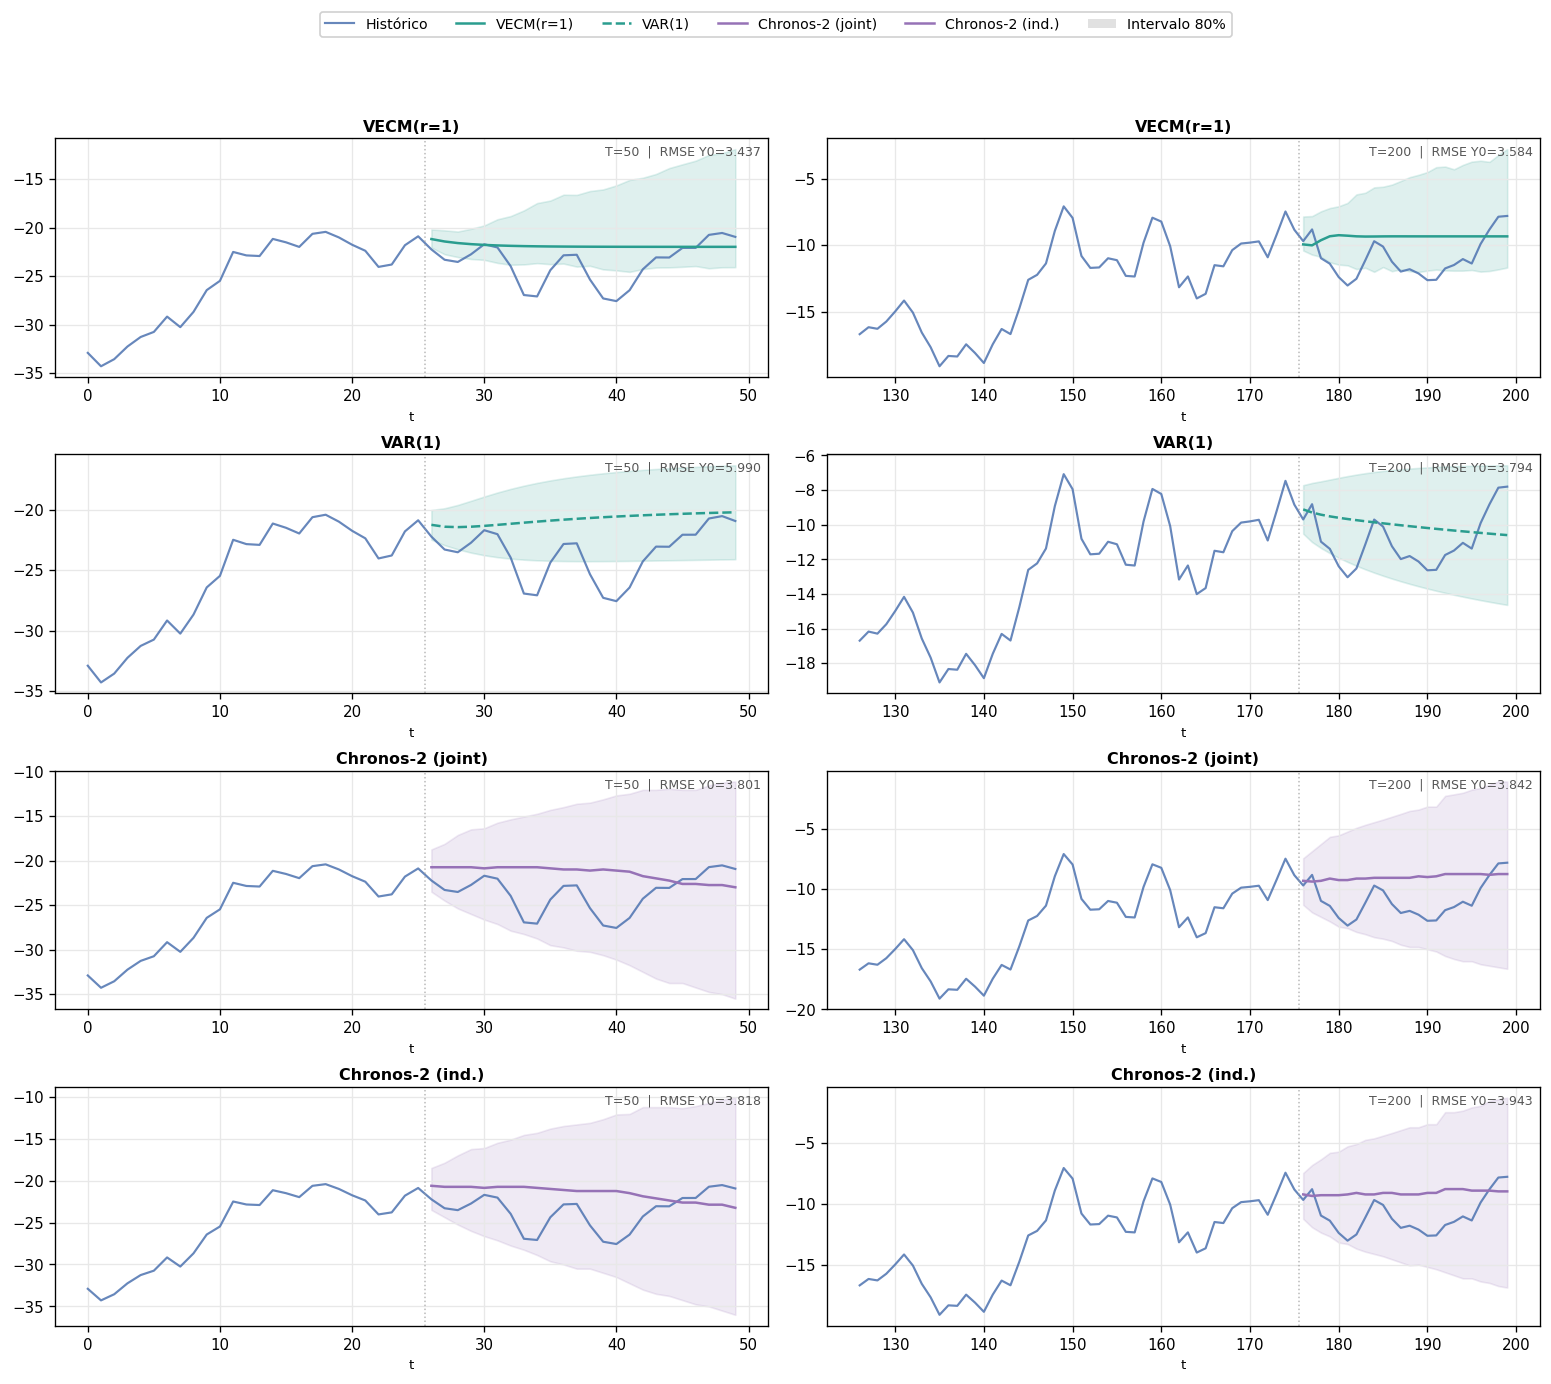

In [48]:
make_models_2_7 = lambda T: [
    VECMModel(coint_rank=1),
    VARModel(1),
    chronos_mv,
    chronos_mv_ind,
]
_ = plot_rep_mv(dgp_2_7, make_models_2_7, title='Exp 2.7 — VECM cointegrado k=2', mc_results=res_2_7)


---

# Experimentos con Covariables

Seleccionados: **3.1** (inversión β fuerte) · **3.4** (VARX sin inversión) · **3.6** (ADL-ECM cointegrado)  

**Supuesto oráculo:** los valores futuros de X se proveen a los modelos — se evalúa la utilidad del covariante dado que su futuro es observable.

## Exp 3.1 — ARIMAX AR(1) con covariante fuerte (β=0.8) *(inversión a T=200)*

**DGP:** $Y_t = 0.6\,Y_{t-1} + 0.8\,X_t + \varepsilon_t$, $X_t = 0.7\,X_{t-1} + \eta_t$

**La inversión más limpia del bloque.** A T=50: SARIMAX domina (+19% RMSE). A T=200: **Chronos gana** (−24% RMSE, −10% CRPS, mejor Winkler). Mecanismo: Chronos aprende implícitamente la relación entre covariante y target desde el contexto cuando la señal es suficientemente fuerte. SARIMAX tiene un techo de mejora limitado por los errores de estimación a largo horizonte.

**Hipótesis:** Inversión a T=200 impulsada por señal fuerte del covariante.

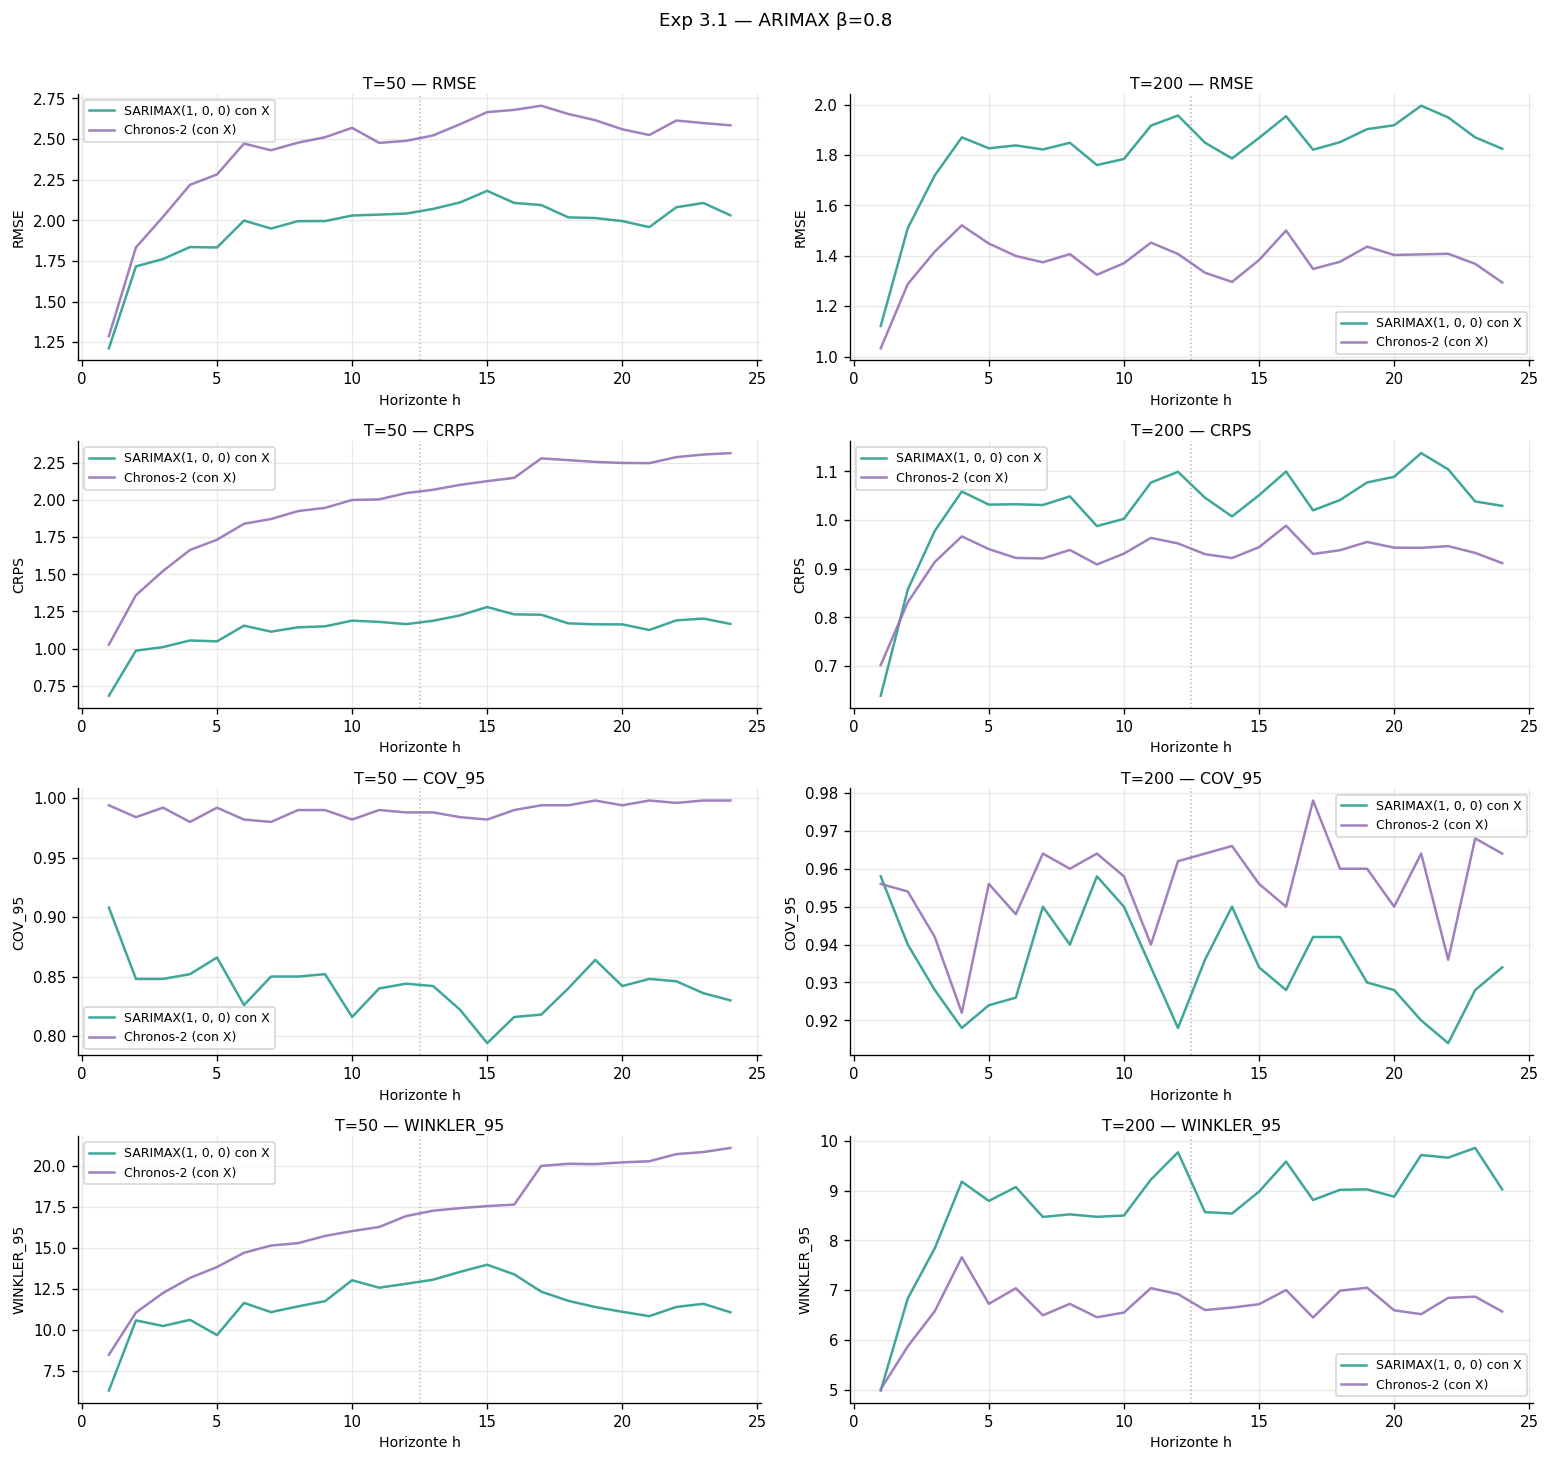

In [49]:
res_3_1 = load_cov('3.1')
styled_table(res_3_1, title='Exp 3.1 — ARIMAX β=0.8')
_ = plot_metrics_horizon(res_3_1, title='Exp 3.1 — ARIMAX β=0.8')


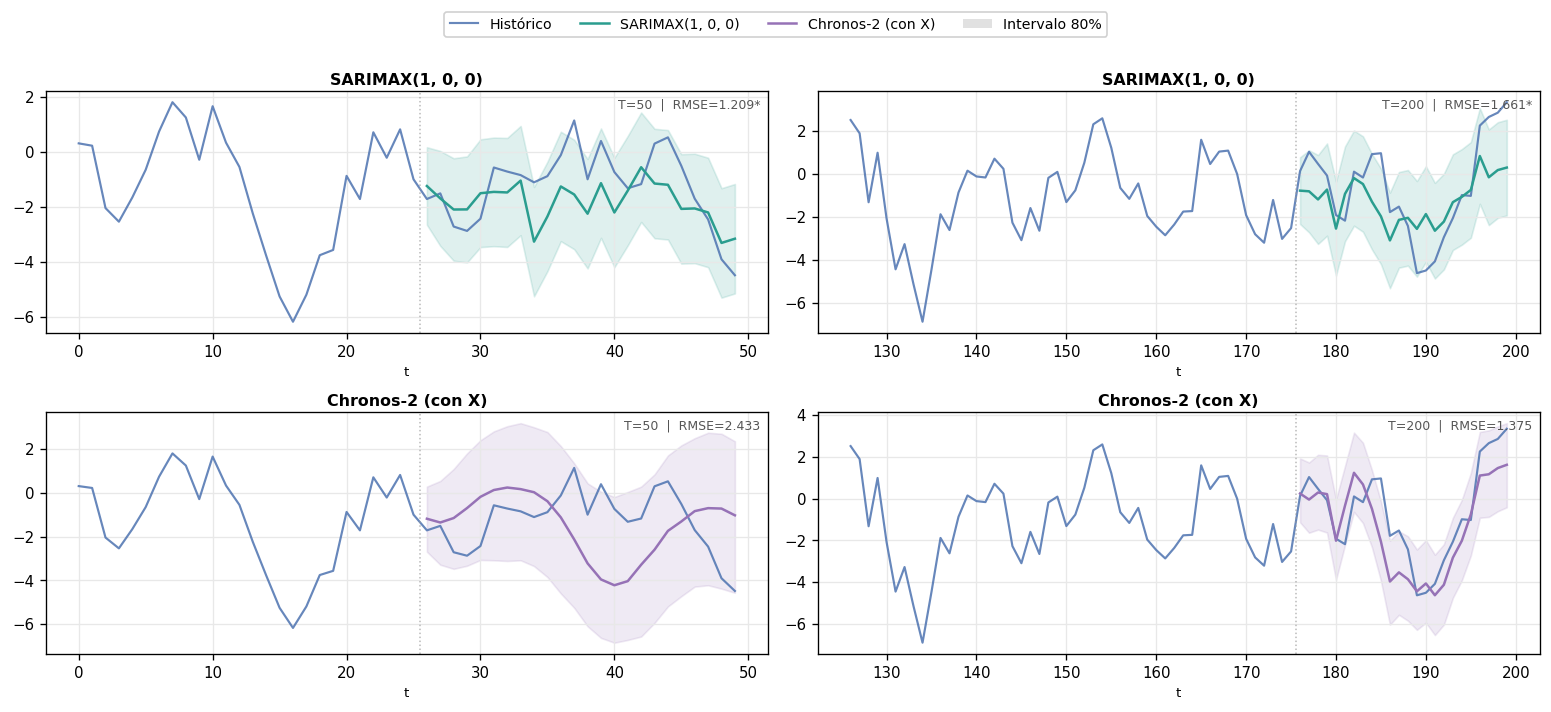

In [50]:
make_models_3_1 = lambda T: [
    SARIMAXModel((1,0,0)),
    chronos_cov1,
]
_ = plot_rep_cov(dgp_3_1, make_models_3_1,
             dgp_params={'phi': 0.6, 'beta': 0.8, 'sigma_y': 1.0, 'sigma_x': 1.0, 'rho_x': 0.7},
             title='Exp 3.1 — ARIMAX β=0.8', mc_results=res_3_1)


## Exp 3.4 — VARX bivariado (VAR con covariante) *(sin inversión)*

**DGP:** $Y_t = A\,Y_{t-1} + \gamma\,X_t + \varepsilon_t$, $A = \begin{pmatrix}0.5&0.1\\0.1&0.5\end{pmatrix}$, $\gamma=(0.5, 0.3)^{\top}$, $X_t = 0.7\,X_{t-1} + \eta_t$

**Contraste directo con Exp 3.1: sin inversión.** VARMAX-OLS domina en todas las métricas en ambos T (+21%/+12% RMSE a T=50, +8% a T=200). La estructura VARX con covariante beneficia al modelo paramétrico: las interdependencias cross-variable están explícitamente representadas en el VAR, mientras Chronos trata cada variable de forma más independiente.

**Hipótesis:** VARMAX domina sin inversión. La dimensionalidad multivariante protege al modelo clásico.

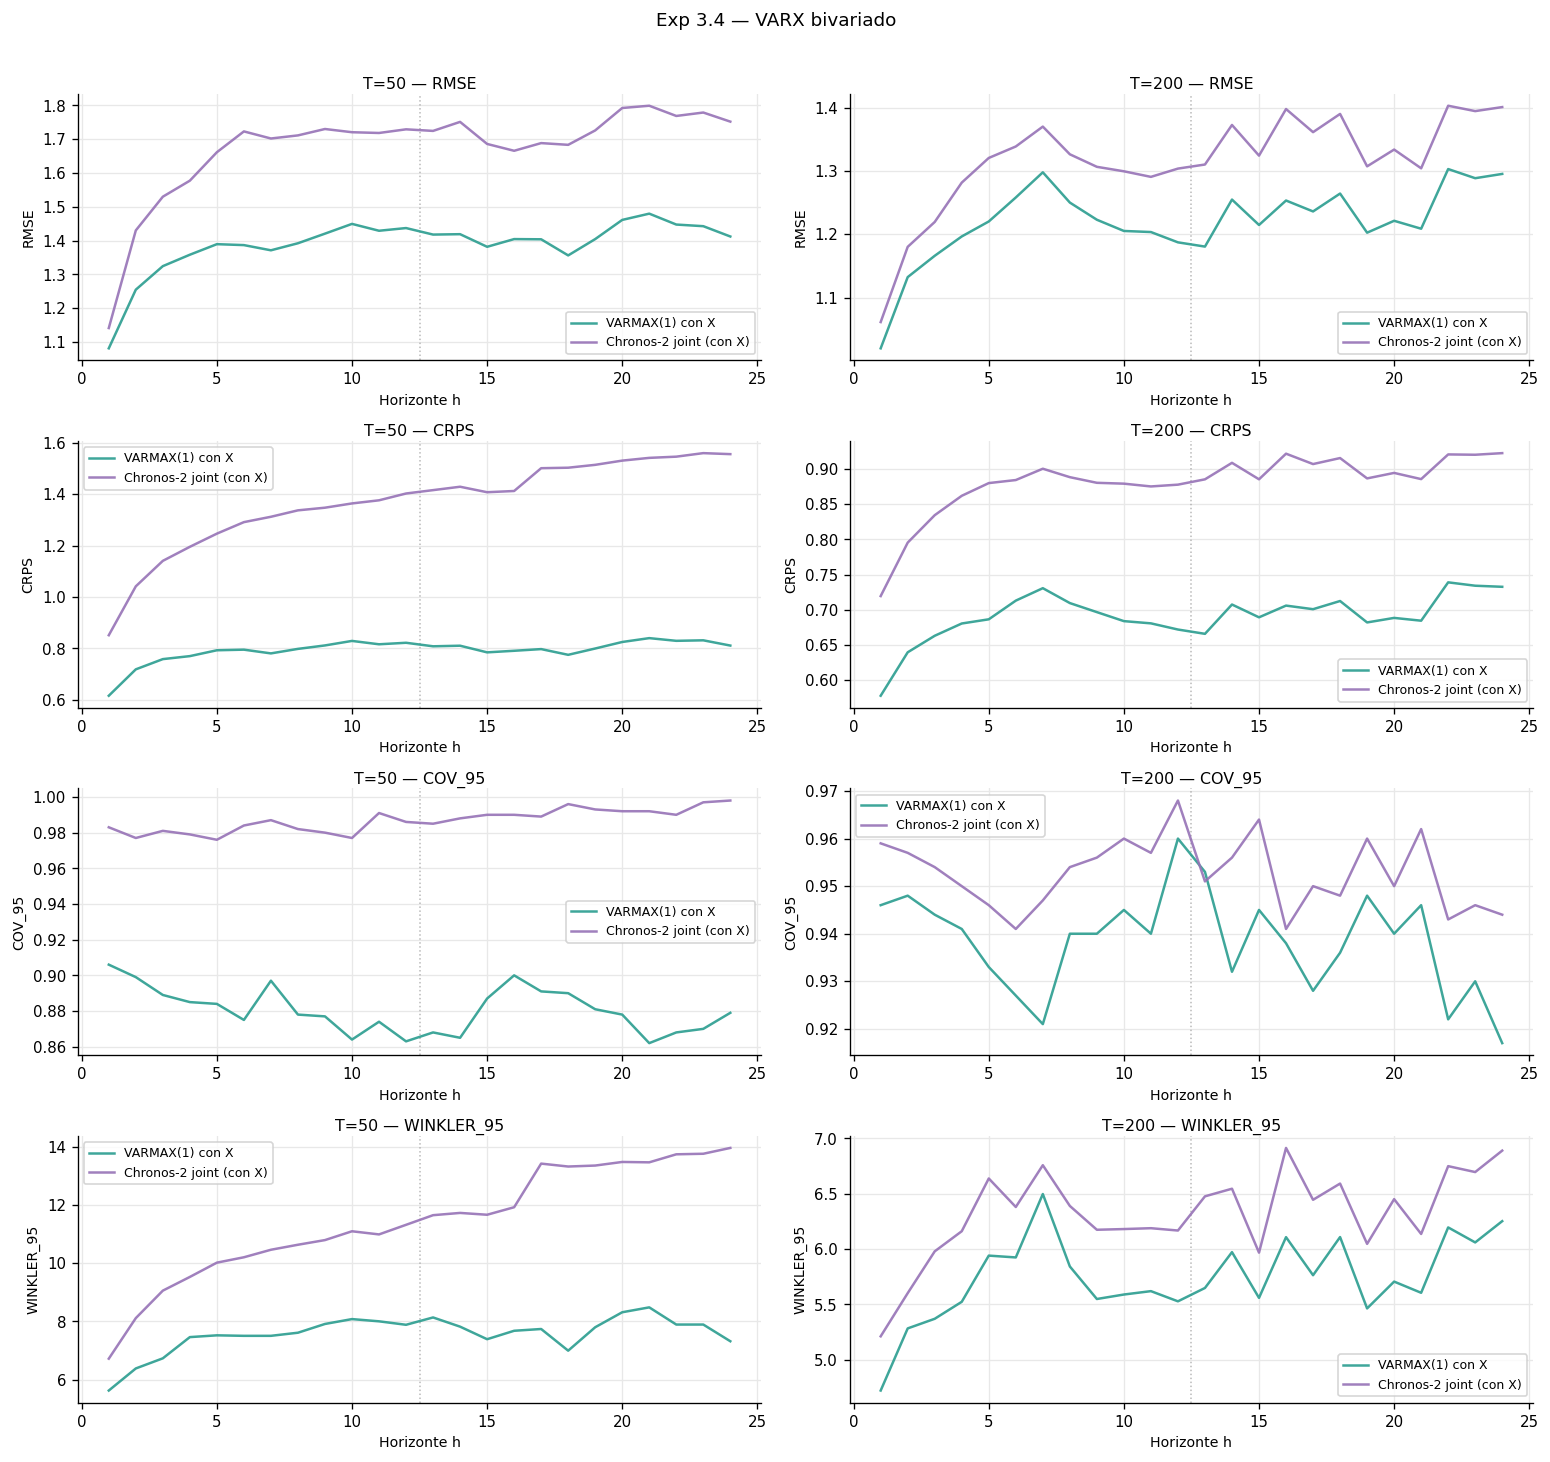

In [51]:
res_3_4 = load_mv_cov('3.4')
styled_table(res_3_4, title='Exp 3.4 — VARX bivariado', is_mv=True)
_ = plot_metrics_horizon(res_3_4, title='Exp 3.4 — VARX bivariado', is_mv=True)


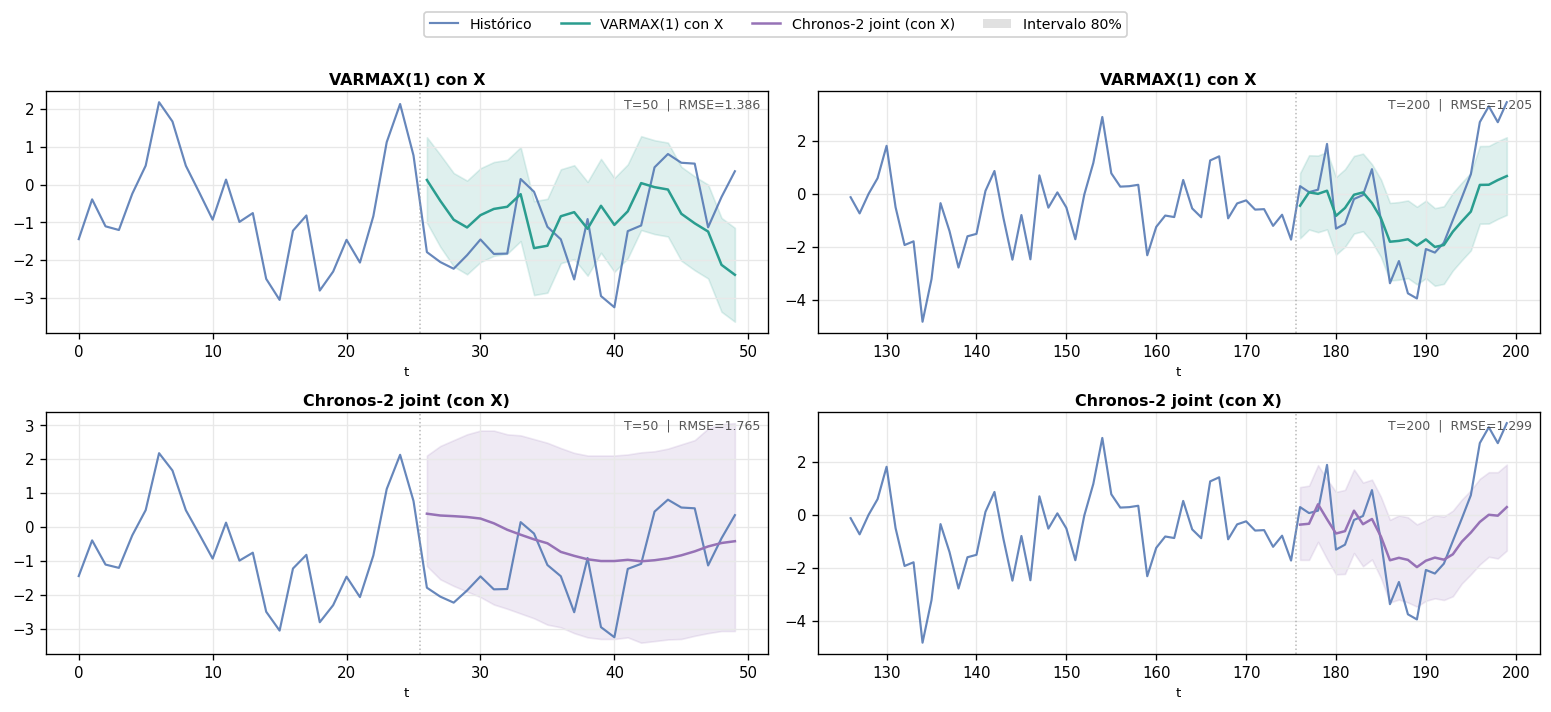

In [52]:
make_models_3_4 = lambda T: [
    VARMAXModel(1),
    chronos_mv_cov1,
]
_ = plot_rep_cov(dgp_3_4, make_models_3_4,
             dgp_params={},  # VARX_DGP: parámetros en __init__
             is_mv=True, var_idx=0,
             title='Exp 3.4 — VARX bivariado', mc_results=res_3_4)


## Exp 3.6 — ADL-ECM cointegrado *(el costo de la misspecificación del orden de integración)*

**DGP:** $X_t = X_{t-1} + u_t$, $\Delta Y_t = -0.3\,(Y_{t-1} - X_{t-1}) + \Delta X_t + \eta_t$ (cointegración con vector $(1,-1)$)

**El más rico metodológicamente.** Ranking RMSE: ARDL-ECM < SARIMAX-niv < Chronos < SARIMAX-dif. Sobrediferenciar es el error más costoso: SARIMAX(1,1,0) es +82% peor en RMSE a T=50 y +40% a T=200 vs ARDL-ECM. SARIMAX en niveles, sin conocer la cointegración, es mucho mejor que SARIMAX diferenciado. Chronos se posiciona entre ambas especificaciones de SARIMAX — captura implícitamente parte de la dinámica de largo plazo.

**Nota:** ARDL-ECM no produce intervalos de predicción.

**Hipótesis:** La correcta especificación del orden de integración es el factor dominante.

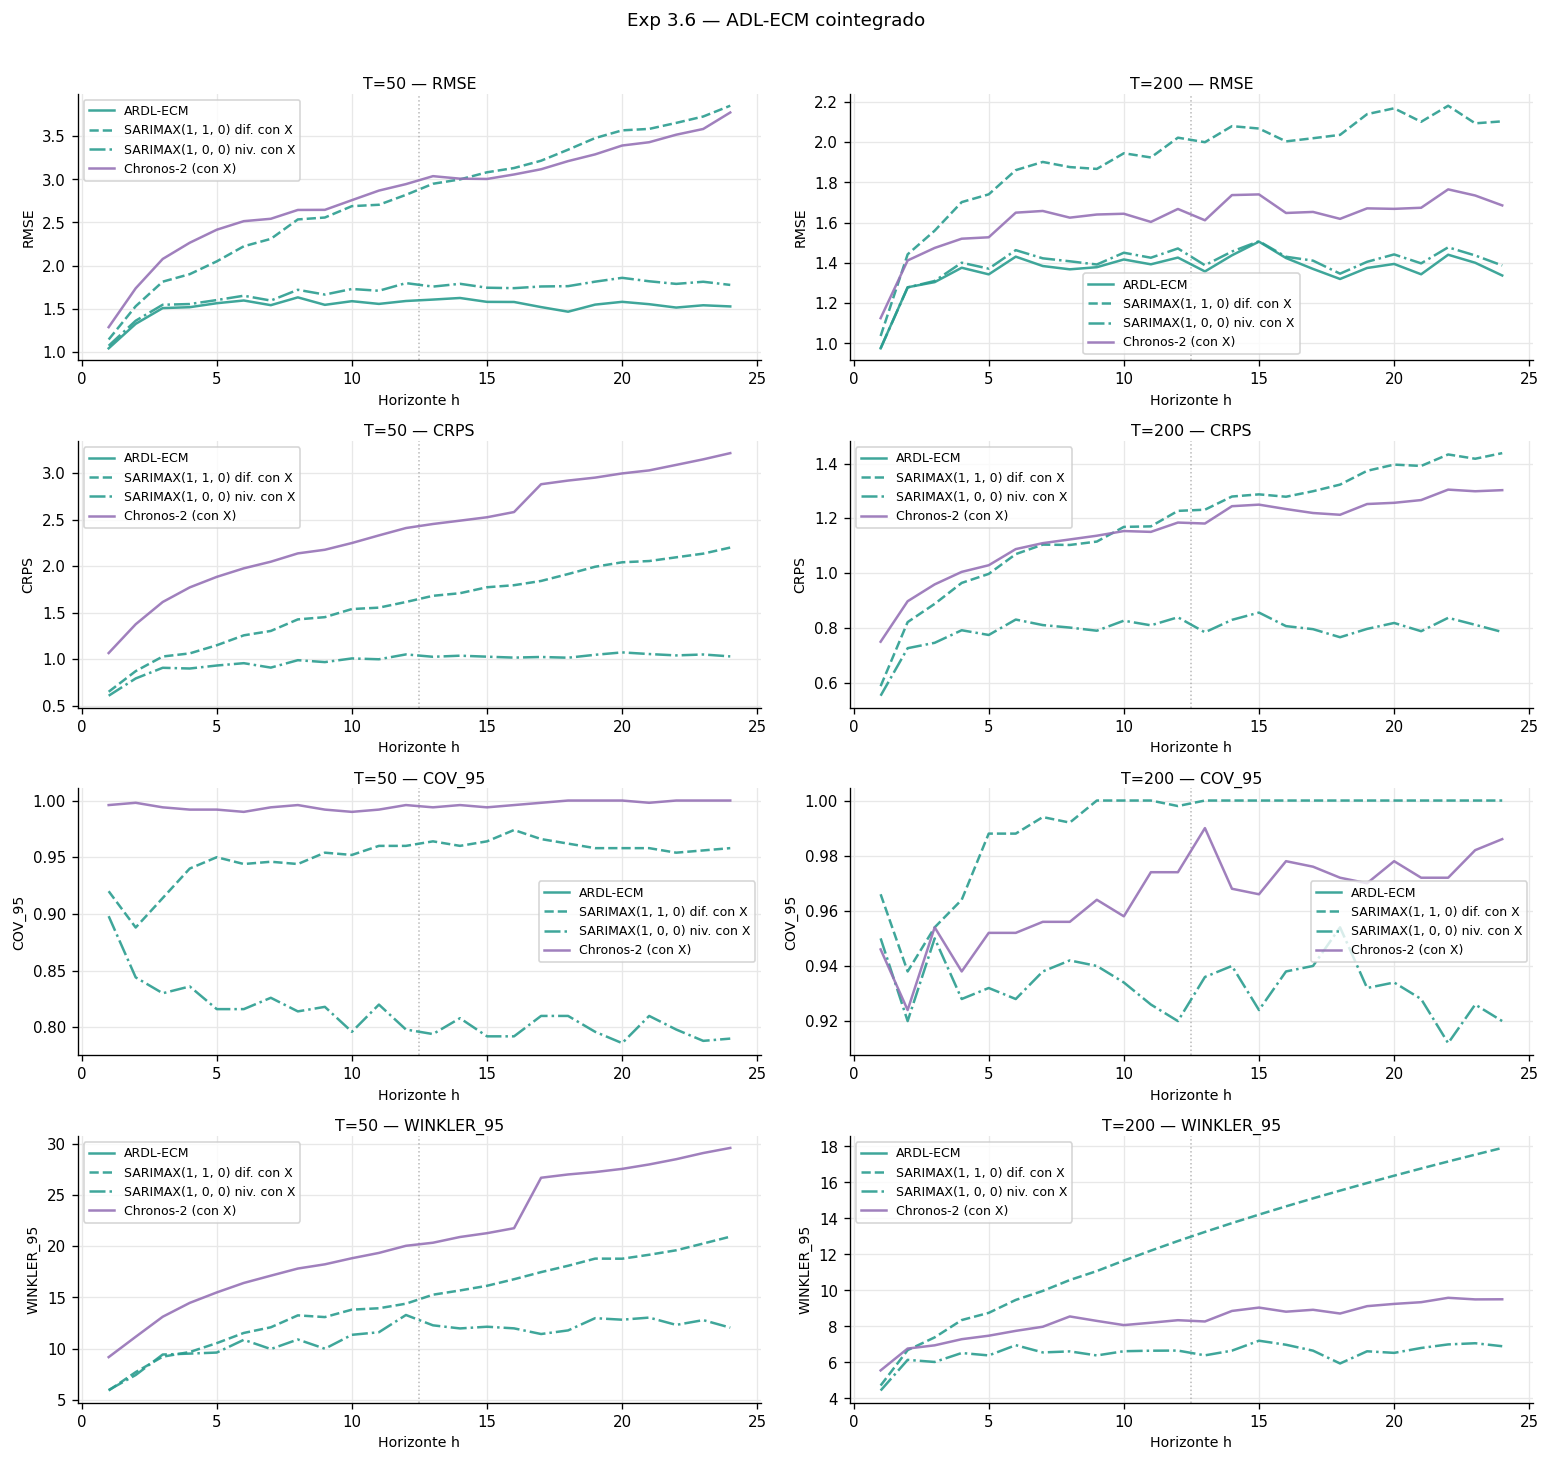

In [53]:
res_3_6 = load_cov('3.6')
styled_table(res_3_6, title='Exp 3.6 — ADL-ECM cointegrado')
_ = plot_metrics_horizon(res_3_6, metrics=('rmse','crps','cov_95','winkler_95'),
                     title='Exp 3.6 — ADL-ECM cointegrado')


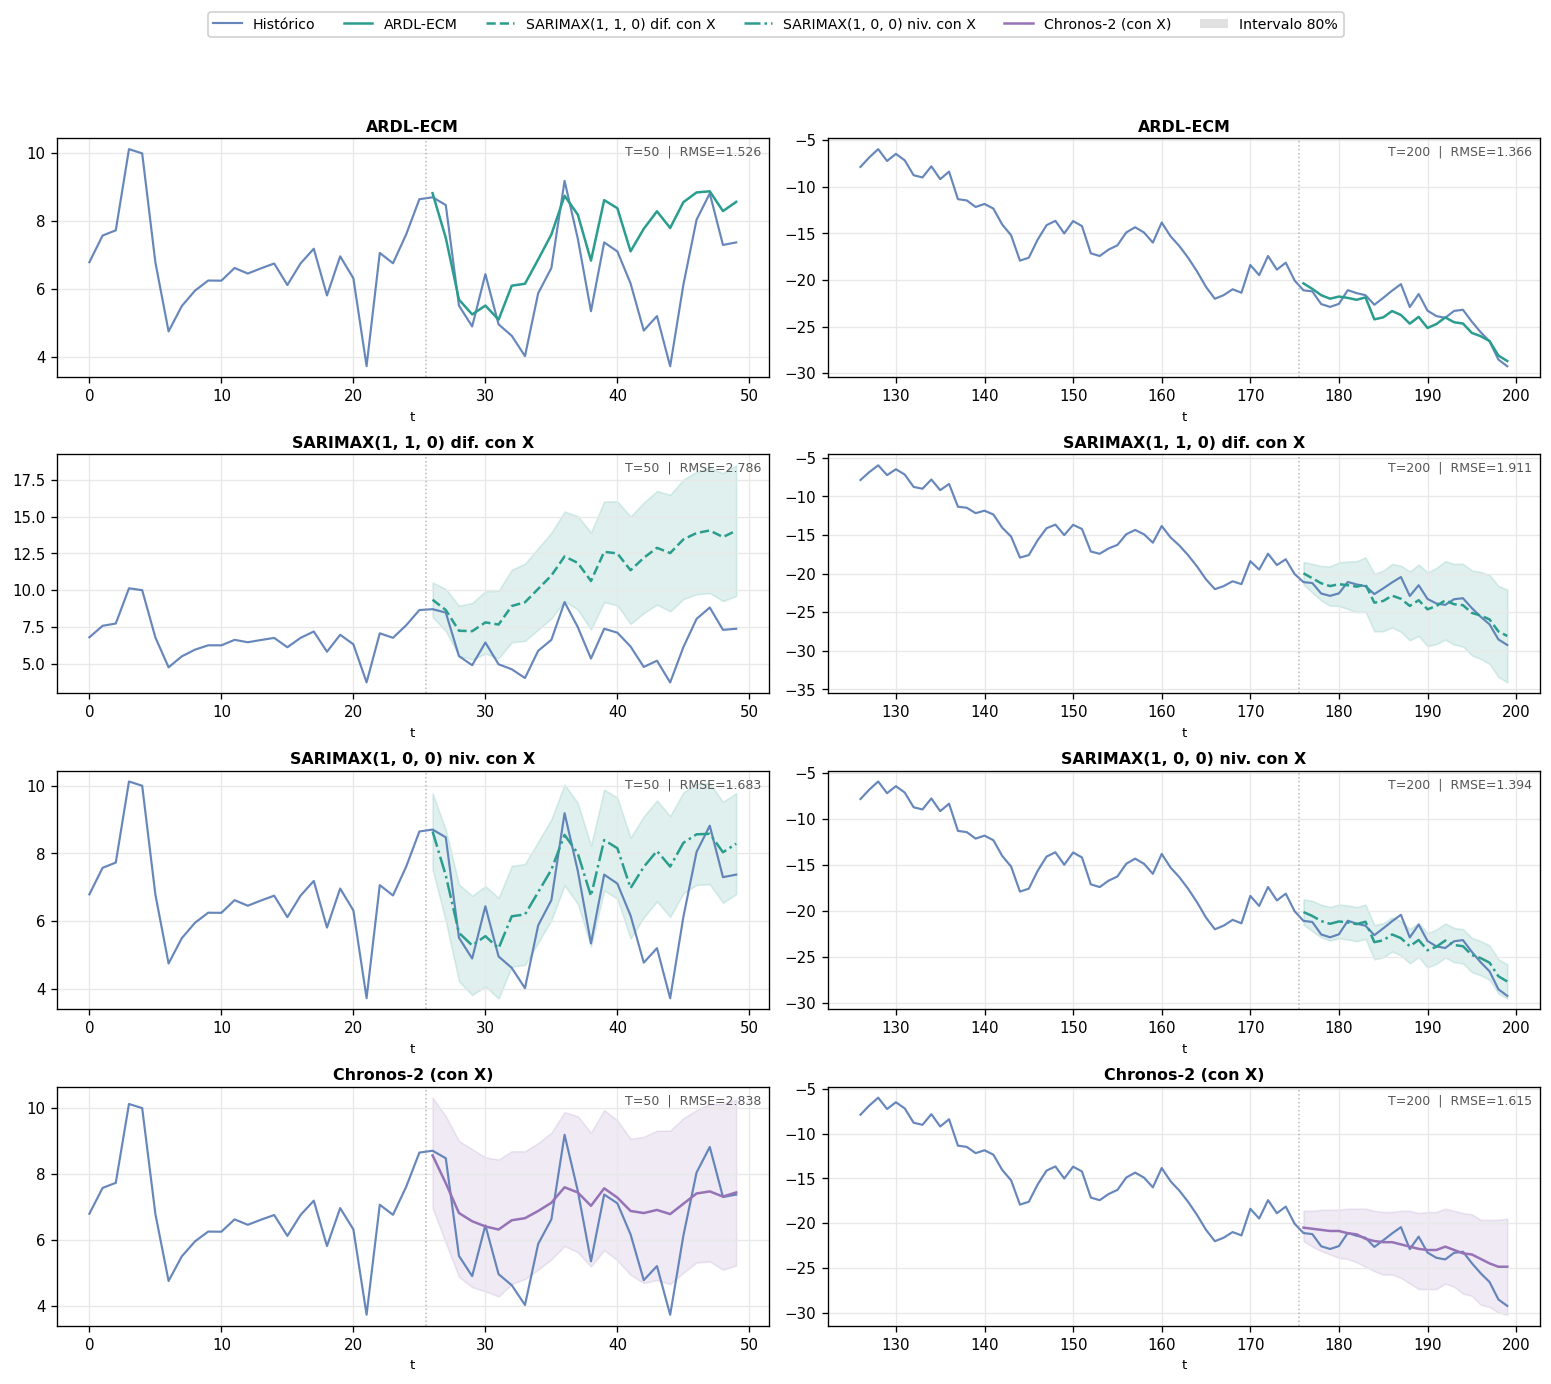

In [54]:
make_models_3_6 = lambda T: [
    ARDLModel(),
    SARIMAXModel((1,1,0), name_suffix='dif. con X'),
    SARIMAXModel((1,0,0), name_suffix='niv. con X'),
    chronos_cov1,
]
_ = plot_rep_cov(dgp_3_6, make_models_3_6,
             dgp_params={'alpha_ecm': -0.3, 'sigma': 1.0, 'sigma_x': 1.0},
             title='Exp 3.6 — ADL-ECM cointegrado', mc_results=res_3_6)
